<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 40px; border-radius: 16px; text-align: center; color: white; margin-bottom: 30px;">
  <h1 style="font-size: 2.8em; margin: 0; font-weight: 800; letter-spacing: 2px;">🌐 Machine Translation: English → Vietnamese</h1>
  <p style="font-size: 1.2em; margin-top: 12px; opacity: 0.9;">Từ Seq2Seq với Attention đến Transformer — Hành trình học NLP chuyên sâu</p>
  <div style="margin-top: 20px; display: flex; justify-content: center; gap: 20px; flex-wrap: wrap;">
    <span style="background: rgba(255,255,255,0.2); padding: 6px 16px; border-radius: 20px; font-size: 0.9em;">🔬 PyTorch</span>
    <span style="background: rgba(255,255,255,0.2); padding: 6px 16px; border-radius: 20px; font-size: 0.9em;">📊 BPE Tokenizer</span>
    <span style="background: rgba(255,255,255,0.2); padding: 6px 16px; border-radius: 20px; font-size: 0.9em;">🤖 Transformer</span>
    <span style="background: rgba(255,255,255,0.2); padding: 6px 16px; border-radius: 20px; font-size: 0.9em;">📈 BLEU Score</span>
  </div>
</div>

## 📋 Mục lục

| # | Phần | Nội dung |
|---|------|----------|
| 1 | ⚙️ Cài đặt môi trường | Cài thư viện, import, cấu hình thiết bị |
| 2 | 📥 Tải dữ liệu | Load dataset IWSLT En-Vi từ Hugging Face |
| 3 | 🔍 Phân tích EDA | Phân phối độ dài, từ phổ biến, dữ liệu nhiễu |
| 4 | 🧹 Tiền xử lý | BPE Tokenizer, Vocabulary, Padding & Masking |
| 5 | 🧠 Seq2Seq + Attention | Kiến trúc, huấn luyện, đánh giá Bahdanau |
| 6 | ⚡ Transformer | Multi-head Attention, Positional Encoding |
| 7 | 🏋️ Huấn luyện | Training loop, Label Smoothing, LR Scheduler |
| 8 | 📊 Đánh giá | BLEU, ROUGE, hàm Inference |

---
> **Dataset**: [IWSLT mt_eng_vietnamese](https://huggingface.co/datasets/IWSLT/mt_eng_vietnamese) — ~2.88M cặp câu song ngữ Anh-Việt
>
> **Tác giả**: Notebook được xây dựng theo phương pháp giảng dạy từ cơ bản đến nâng cao, có giải thích lý thuyết chi tiết.

In [1]:
# Cài đặt các thư viện cần thiết
!pip install -q rouge_score sacrebleu tokenizers datasets wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.6 MB/s eta 0:00:00


In [2]:
# =============================================================
#  IMPORT THƯ VIỆN
# =============================================================

# --- Thư viện cơ bản ---
import numpy as np
import pandas as pd
import re
import math
import random
import time
import os
import copy
from collections import Counter
from tqdm.auto import tqdm

# --- Trực quan hóa ---
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Cấu hình style cho biểu đồ đẹp hơn
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#e6edf3',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans'
})
PALETTE = ['#58a6ff', '#3fb950', '#d2a8ff', '#ffa657', '#ff7b72', '#79c0ff']

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# --- Tokenizer (HuggingFace) ---
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import Lowercase, NFD, StripAccents, Sequence as NormSeq

# --- Đánh giá ---
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import sacrebleu
from rouge_score import rouge_scorer

# --- Dataset ---
from datasets import load_dataset

# =============================================================
#  CẤU HÌNH THIẾT BỊ
# =============================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{'='*50}")
print(f"  🖥️  Thiết bị đang sử dụng: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  🎮  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  💾  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"{'='*50}")

# Đặt seed để tái lập kết quả
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
print("\n✅ Seed cố định tại:", SEED)

  🖥️  Thiết bị đang sử dụng: cuda
  🎮  GPU: Tesla T4
  💾  VRAM: 15.6 GB

✅ Seed cố định tại: 42


---
# 📥 Phần 2: Tải Dữ liệu

Chúng ta sử dụng dataset **IWSLT mt_eng_vietnamese** — một benchmark chuẩn trong cộng đồng NLP cho cặp ngôn ngữ Anh-Việt.

| Split | Số mẫu | Mục đích |
|-------|--------|----------|
| Train | ~2.88M | Huấn luyện mô hình |
| Validation | ~11K | Theo dõi overfitting |
| Test | ~12K | Đánh giá cuối cùng |

> **Lưu ý**: Để notebook chạy nhanh, ta dùng một **subset** nhỏ hơn trong demo. Khi huấn luyện thật, tăng `MAX_SAMPLES` lên.

In [3]:
# =============================================================
#  TẢI DATASET
# =============================================================

print("📥 Đang tải dataset En-Vi từ Hugging Face (ncduy/mt-en-vi)...")
raw_dataset = load_dataset("ncduy/mt-en-vi")
print("\n✅ Tải xong!")
print(raw_dataset)

# Giới hạn kích thước cho demo (comment dòng này khi chạy đầy đủ)
MAX_SAMPLES  = 100_000  # Tăng lên 500_000 hoặc None để dùng toàn bộ
MAX_VAL_TEST = 5_000

# Trích xuất cặp câu (en, vi) từ dataset
def extract_pairs(split, max_n=None):
    """Trích xuất list các tuple (en_sentence, vi_sentence)"""
    pairs = []
    data = raw_dataset[split]
    if max_n:
        data = data.select(range(min(max_n, len(data))))
    for item in data:
        en = item['en']
        vi = item['vi']
        pairs.append((en, vi))
    return pairs

train_pairs = extract_pairs('train',      MAX_SAMPLES)
val_pairs   = extract_pairs('validation', MAX_VAL_TEST)
test_pairs  = extract_pairs('test',       MAX_VAL_TEST)

print(f"\n📊 Kích thước dataset sau khi lọc:")
print(f"  • Train     : {len(train_pairs):,} cặp câu")
print(f"  • Validation: {len(val_pairs):,} cặp câu")
print(f"  • Test      : {len(test_pairs):,} cặp câu")

print("\n🔎 Ví dụ 3 cặp câu đầu:")
for i, (en, vi) in enumerate(train_pairs[:3]):
    print(f"  [{i+1}] EN: {en}")
    print(f"      VI: {vi}")
    print()

📥 Đang tải dataset En-Vi từ Hugging Face (ncduy/mt-en-vi)...


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/597M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/2.45M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/2.43M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2884451 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11316 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11225 [00:00<?, ? examples/s]


✅ Tải xong!
DatasetDict({
    train: Dataset({
        features: ['en', 'vi', 'source'],
        num_rows: 2884451
    })
    validation: Dataset({
        features: ['en', 'vi', 'source'],
        num_rows: 11316
    })
    test: Dataset({
        features: ['en', 'vi', 'source'],
        num_rows: 11225
    })
})

📊 Kích thước dataset sau khi lọc:
  • Train     : 100,000 cặp câu
  • Validation: 5,000 cặp câu
  • Test      : 5,000 cặp câu

🔎 Ví dụ 3 cặp câu đầu:
  [1] EN: - Sorry, that question's not on here.
      VI: - Xin lỗi, nhưng mà ở đây không có câu hỏi đấy.

  [2] EN: He wants you to come with him immediately.
      VI: Ông ấy muốn bố đi với ông ấy ngay lập tức

  [3] EN: I thought we could use some company.
      VI: Tôi nghĩ chúng ta có thể muốn vài người bạn đồng hành.



---
# 🔍 Phần 3: Phân tích Khám phá Dữ liệu (EDA)

**Tại sao cần EDA?**

Trước khi huấn luyện mô hình, ta phải **hiểu rõ dữ liệu** để:
1. Phát hiện **dữ liệu nhiễu** (dòng rỗng, trùng lặp, ký tự lạ) → làm sạch trước khi train
2. Biết **phân phối độ dài câu** → chọn `max_len` phù hợp, tránh cắt quá nhiều thông tin
3. Phân tích **từ vựng phổ biến** → đặt kích thước vocabulary hợp lý
4. Đánh giá **tỷ lệ căn chỉnh** (alignment ratio) → phát hiện dữ liệu dịch kém chất lượng

In [4]:
# =============================================================
#  3.1 — KIỂM TRA & XỬ LÝ DỮ LIỆU NHIỄU
# =============================================================

print("🧹 Kiểm tra dữ liệu nhiễu...\n")

df = pd.DataFrame(train_pairs, columns=['en', 'vi'])
original_size = len(df)

# --- 1. Kiểm tra giá trị null ---
null_counts = df.isnull().sum()
print(f"[1] Giá trị null:\n{null_counts}\n")

# --- 2. Kiểm tra dòng rỗng ---
empty_en = (df['en'].str.strip() == '').sum()
empty_vi = (df['vi'].str.strip() == '').sum()
print(f"[2] Dòng rỗng — EN: {empty_en}, VI: {empty_vi}")

# --- 3. Kiểm tra trùng lặp ---
dup_count = df.duplicated().sum()
print(f"[3] Cặp câu trùng lặp: {dup_count:,}")

# --- 4. Kiểm tra ký tự đặc biệt bất thường ---
# Regex phát hiện chuỗi chỉ có ký tự đặc biệt / số (không có chữ cái)
noise_pattern = re.compile(r'^[^a-zA-Zàáảãạăắằẳẵặâấầẩẫậđèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵ]+$')
noisy_en = df['en'].apply(lambda x: bool(noise_pattern.match(str(x).strip()))).sum()
noisy_vi = df['vi'].apply(lambda x: bool(noise_pattern.match(str(x).strip()))).sum()
print(f"[4] Dòng nhiễu (chỉ ký tự đặc biệt) — EN: {noisy_en}, VI: {noisy_vi}")

# --- 5. Kiểm tra tỷ lệ độ dài (alignment ratio) ---
# Nếu một câu tiếng Việt quá ngắn/dài so với tiếng Anh → có thể dịch sai
df['len_en'] = df['en'].str.split().str.len()
df['len_vi'] = df['vi'].str.split().str.len()
df['ratio']  = df['len_vi'] / (df['len_en'] + 1e-8)
extreme_ratio = ((df['ratio'] < 0.3) | (df['ratio'] > 3.0)).sum()
print(f"[5] Cặp câu có tỷ lệ độ dài bất thường (ratio<0.3 hoặc >3.0): {extreme_ratio:,}")

# =============================================================
#  LÀM SẠCH DỮ LIỆU
# =============================================================
print("\n🔧 Đang làm sạch...")

# Xóa null, rỗng
df = df.dropna(subset=['en', 'vi'])
df = df[df['en'].str.strip() != '']
df = df[df['vi'].str.strip() != '']

# Xóa trùng lặp
df = df.drop_duplicates()

# Loại bỏ tỷ lệ độ dài bất thường
df = df[(df['ratio'] >= 0.3) & (df['ratio'] <= 3.0)]

# Loại bỏ câu quá ngắn (< 3 từ) hoặc quá dài (> 100 từ)
df = df[(df['len_en'] >= 3) & (df['len_en'] <= 100)]
df = df[(df['len_vi'] >= 3) & (df['len_vi'] <= 100)]

cleaned_size = len(df)
removed = original_size - cleaned_size
print(f"\n✅ Kết quả làm sạch:")
print(f"  • Dữ liệu gốc     : {original_size:,} cặp")
print(f"  • Đã loại bỏ      : {removed:,} cặp ({removed/original_size*100:.1f}%)")
print(f"  • Còn lại          : {cleaned_size:,} cặp")

# Cập nhật lại train_pairs sau khi làm sạch
train_pairs = list(zip(df['en'].tolist(), df['vi'].tolist()))

🧹 Kiểm tra dữ liệu nhiễu...

[1] Giá trị null:
en    0
vi    0
dtype: int64

[2] Dòng rỗng — EN: 0, VI: 0
[3] Cặp câu trùng lặp: 0
[4] Dòng nhiễu (chỉ ký tự đặc biệt) — EN: 0, VI: 0
[5] Cặp câu có tỷ lệ độ dài bất thường (ratio<0.3 hoặc >3.0): 297

🔧 Đang làm sạch...

✅ Kết quả làm sạch:
  • Dữ liệu gốc     : 100,000 cặp
  • Đã loại bỏ      : 582 cặp (0.6%)
  • Còn lại          : 99,418 cặp


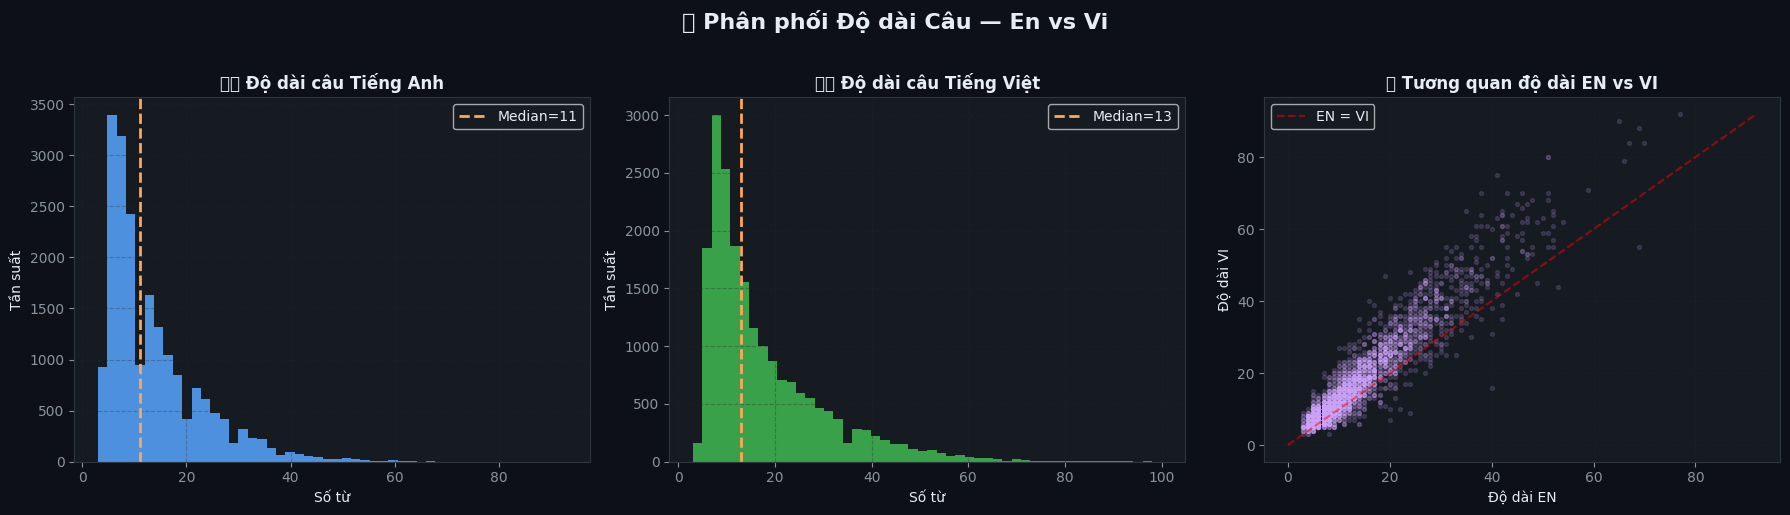


📊 Thống kê mô tả độ dài câu:
        English  Vietnamese
count  99418.00    99418.00
mean      13.78       17.86
std        9.46       12.93
min        3.00        3.00
25%        7.00        8.00
50%       11.00       13.00
75%       18.00       23.00
max       97.00      100.00

💡 Gợi ý MAX_LEN: 33 từ (bao phủ 95% câu EN)


In [5]:
# =============================================================
#  3.2 — TRỰC QUAN HÓA PHÂN PHỐI ĐỘ DÀI CÂU
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📏 Phân phối Độ dài Câu — En vs Vi', fontsize=16, fontweight='bold', color='#e6edf3', y=1.02)

# Lấy sample để vẽ nhanh
sample_df = df.sample(min(20000, len(df)), random_state=42)

# --- Biểu đồ 1: Histogram độ dài EN ---
ax = axes[0]
ax.hist(sample_df['len_en'], bins=50, color=PALETTE[0], alpha=0.85, edgecolor='none')
ax.axvline(sample_df['len_en'].median(), color='#ffa657', linestyle='--', linewidth=2, label=f'Median={sample_df["len_en"].median():.0f}')
ax.set_title('🇺🇸 Độ dài câu Tiếng Anh', fontweight='bold')
ax.set_xlabel('Số từ')
ax.set_ylabel('Tần suất')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Biểu đồ 2: Histogram độ dài VI ---
ax = axes[1]
ax.hist(sample_df['len_vi'], bins=50, color=PALETTE[1], alpha=0.85, edgecolor='none')
ax.axvline(sample_df['len_vi'].median(), color='#ffa657', linestyle='--', linewidth=2, label=f'Median={sample_df["len_vi"].median():.0f}')
ax.set_title('🇻🇳 Độ dài câu Tiếng Việt', fontweight='bold')
ax.set_xlabel('Số từ')
ax.set_ylabel('Tần suất')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Biểu đồ 3: Scatter plot EN vs VI length ---
ax = axes[2]
mini = sample_df.sample(3000, random_state=42)
ax.scatter(mini['len_en'], mini['len_vi'], alpha=0.15, s=8, color=PALETTE[2])
max_val = max(mini['len_en'].max(), mini['len_vi'].max())
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='EN = VI')
ax.set_title('🔗 Tương quan độ dài EN vs VI', fontweight='bold')
ax.set_xlabel('Độ dài EN')
ax.set_ylabel('Độ dài VI')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Thống kê mô tả
print("\n📊 Thống kê mô tả độ dài câu:")
stats = df[['len_en', 'len_vi']].describe().round(2)
stats.columns = ['English', 'Vietnamese']
print(stats.to_string())
print(f"\n💡 Gợi ý MAX_LEN: {int(df['len_en'].quantile(0.95))} từ (bao phủ 95% câu EN)")

Đang đếm từ:   0%|          | 0/50000 [00:00<?, ?it/s]

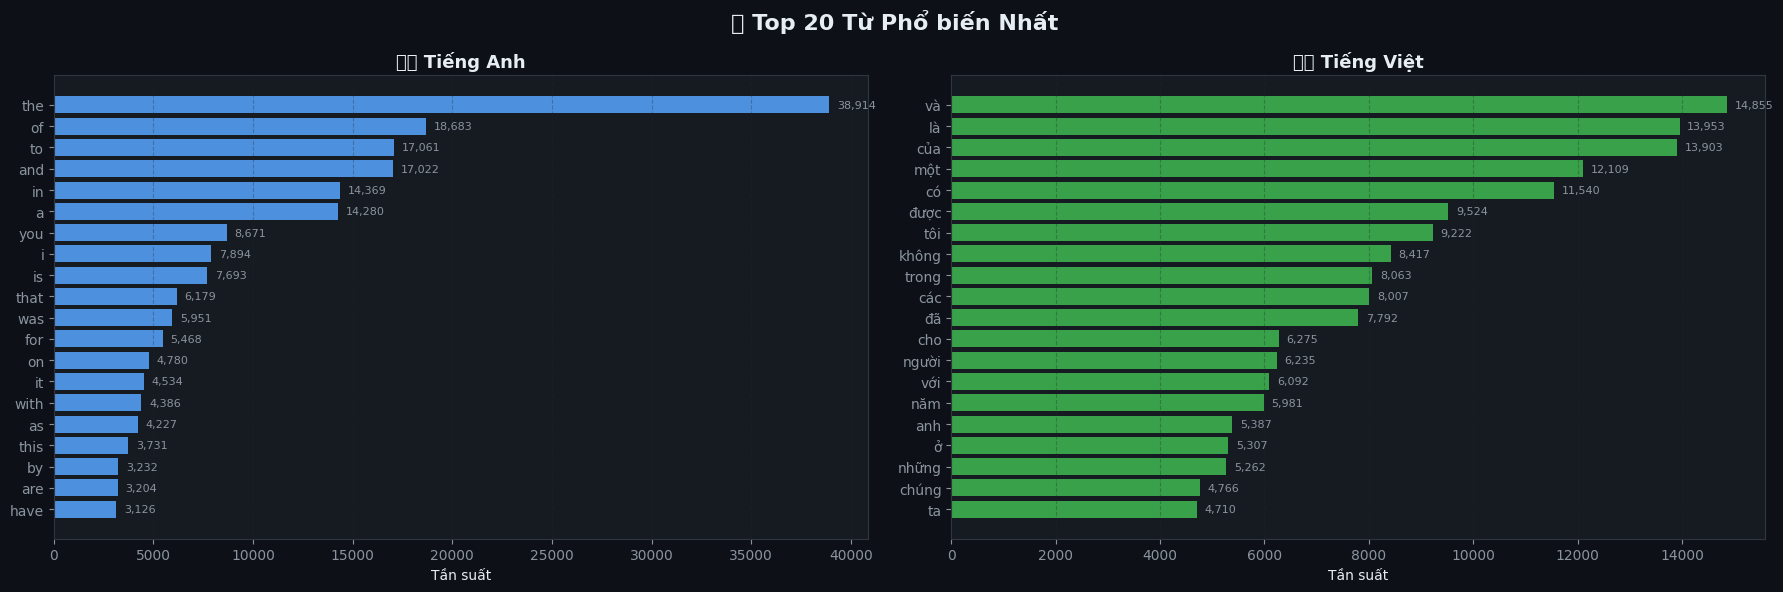

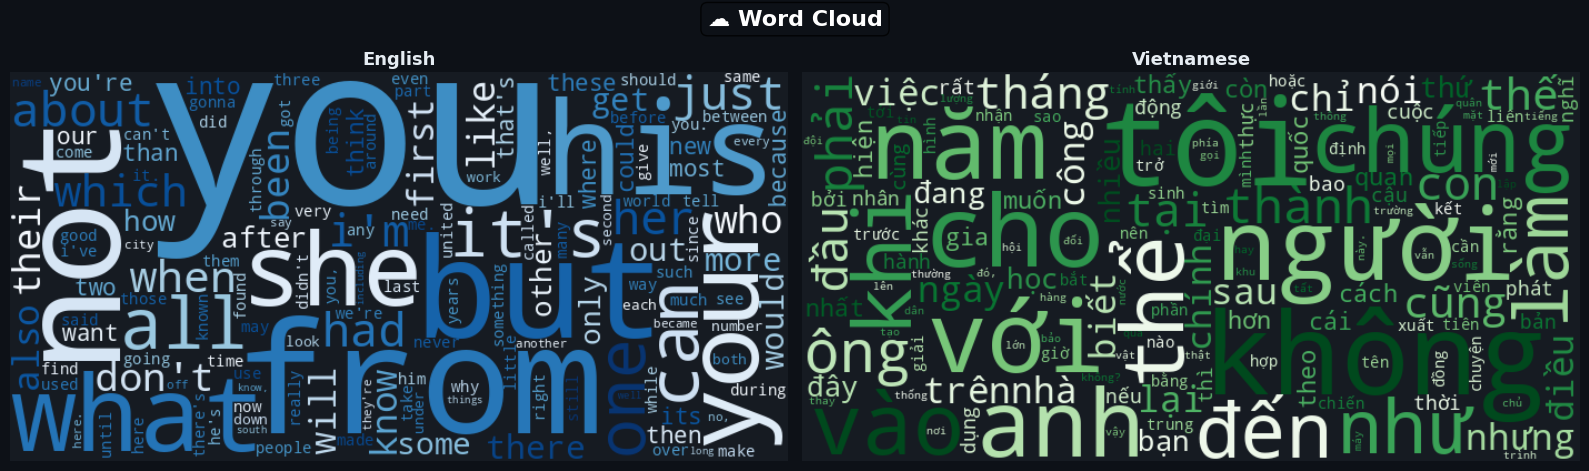


📚 Kích thước từ vựng (word-level):
  • Tiếng Anh : 81,914 từ duy nhất
  • Tiếng Việt: 53,531 từ duy nhất
  → Đây là lý do tại sao ta dùng BPE thay vì word-level
    (BPE giảm vocabulary xuống còn ~8K-16K tokens, tổng quát hơn)


In [6]:
# =============================================================
#  3.3 — THỐNG KÊ TỪ PHỔ BIẾN & WORDCLOUD
# =============================================================

# Đếm từ (word-level) để phân tích — BPE sẽ dùng ở bước sau
en_words = Counter()
vi_words = Counter()

for en, vi in tqdm(train_pairs[:50_000], desc="Đang đếm từ"):
    en_words.update(en.lower().split())
    vi_words.update(vi.lower().split())

# --- Top 20 từ phổ biến ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('🔤 Top 20 Từ Phổ biến Nhất', fontsize=16, fontweight='bold', color='#e6edf3')

for ax, word_counts, lang, color in zip(
    axes,
    [en_words, vi_words],
    ['🇺🇸 Tiếng Anh', '🇻🇳 Tiếng Việt'],
    [PALETTE[0], PALETTE[1]]
):
    top20 = word_counts.most_common(20)
    words, counts = zip(*top20)
    bars = ax.barh(list(reversed(words)), list(reversed(counts)), color=color, alpha=0.85, edgecolor='none')
    ax.set_title(lang, fontweight='bold', fontsize=13)
    ax.set_xlabel('Tần suất')
    ax.grid(True, alpha=0.3, axis='x')
    # Thêm label số
    for bar, count in zip(bars, reversed(counts)):
        ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                f'{count:,}', va='center', fontsize=8, color='#8b949e')

plt.tight_layout()
plt.show()

# --- WordCloud ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('☁️ Word Cloud', fontsize=16, fontweight='bold', color='white',
             bbox=dict(boxstyle='round', facecolor='#0d1117', alpha=0.8))

for ax, word_counts, lang in zip(axes, [en_words, vi_words], ['English', 'Vietnamese']):
    # Loại bỏ stop words phổ biến để wordcloud thú vị hơn
    stop = {'the','a','an','is','are','was','were','and','of','to','in','that',
            'it','this','for','on','with','be','have','has','i','we','they',
            'là','của','và','trong','có','được','này','đó','các','một','những'}
    filtered = {w: c for w, c in word_counts.items() if w not in stop and len(w) > 2}
    wc = WordCloud(width=700, height=350, background_color='#161b22',
                   colormap='Blues' if 'English' in lang else 'Greens',
                   max_words=150, prefer_horizontal=0.9)
    wc.generate_from_frequencies(filtered)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(lang, fontweight='bold', color='#e6edf3', fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n📚 Kích thước từ vựng (word-level):")
print(f"  • Tiếng Anh : {len(en_words):,} từ duy nhất")
print(f"  • Tiếng Việt: {len(vi_words):,} từ duy nhất")
print(f"  → Đây là lý do tại sao ta dùng BPE thay vì word-level")
print(f"    (BPE giảm vocabulary xuống còn ~8K-16K tokens, tổng quát hơn)")

---
# 🧹 Phần 4: Quy trình Tiền xử lý (Preprocessing Pipeline)

## 4.1 — BPE Tokenizer: Tại sao không dùng Word-level?

| Phương pháp | Vấn đề |
|-------------|--------|
| **Character-level** | Sequence quá dài, mất ngữ nghĩa từ |
| **Word-level** | OOV (Out-of-Vocabulary) với từ mới, vocabulary khổng lồ |
| **BPE (Byte-Pair Encoding)** ✅ | Cân bằng: xử lý được từ lạ, vocabulary nhỏ, không mất thông tin |

**BPE hoạt động như thế nào?**
1. Bắt đầu với bảng chữ cái (characters)
2. Đếm cặp ký tự/subword xuất hiện nhiều nhất → merge thành 1 token mới
3. Lặp lại cho đến khi đạt kích thước vocabulary mong muốn

*Ví dụ:* `"understanding"` → `["under", "stand", "ing"]` — Mô hình vẫn hiểu từ mới `"misunderstanding"`!

In [7]:
# =============================================================
#  4.1 — XÂY DỰNG BPE TOKENIZER
# =============================================================

# Các token đặc biệt cần thiết cho Seq2Seq
SPECIAL_TOKENS = {
    'PAD': '[PAD]',  # Padding: làm đầy câu ngắn hơn trong batch
    'UNK': '[UNK]',  # Unknown: token không có trong vocabulary
    'BOS': '[BOS]',  # Beginning of Sentence: tín hiệu bắt đầu dịch
    'EOS': '[EOS]',  # End of Sentence: tín hiệu kết thúc dịch
}

VOCAB_SIZE    = 16_000  # Kích thước vocabulary cho mỗi ngôn ngữ
MIN_FREQUENCY = 2       # Token phải xuất hiện ít nhất 2 lần

def build_bpe_tokenizer(sentences, vocab_size, special_tokens, save_path=None):
    """
    Xây dựng BPE Tokenizer từ danh sách câu.

    Args:
        sentences: List[str] — danh sách câu để huấn luyện tokenizer
        vocab_size: int — kích thước vocabulary mục tiêu
        special_tokens: List[str] — danh sách token đặc biệt
        save_path: str — đường dẫn lưu file tokenizer (optional)

    Returns:
        tokenizer: Tokenizer đã được huấn luyện
    """
    # Khởi tạo model BPE
    tokenizer = Tokenizer(BPE(unk_token='[UNK]'))

    # Pre-tokenizer: tách theo khoảng trắng (trước khi BPE merge)
    tokenizer.pre_tokenizer = Whitespace()

    # Trainer với cấu hình
    trainer = BpeTrainer(
        vocab_size=vocab_size,
        min_frequency=MIN_FREQUENCY,
        special_tokens=special_tokens,
        show_progress=True
    )

    # Huấn luyện tokenizer trên dữ liệu
    tokenizer.train_from_iterator(sentences, trainer=trainer)

    # Lưu nếu cần
    if save_path:
        tokenizer.save(save_path)

    return tokenizer

# Tách câu EN và VI
en_sentences = [pair[0] for pair in train_pairs]
vi_sentences = [pair[1] for pair in train_pairs]

special_tokens_list = list(SPECIAL_TOKENS.values())

# Huấn luyện tokenizer cho từng ngôn ngữ
print("🔨 Đang huấn luyện BPE Tokenizer cho Tiếng Anh...")
en_tokenizer = build_bpe_tokenizer(en_sentences, VOCAB_SIZE, special_tokens_list)

print("\n🔨 Đang huấn luyện BPE Tokenizer cho Tiếng Việt...")
vi_tokenizer = build_bpe_tokenizer(vi_sentences, VOCAB_SIZE, special_tokens_list)

# Trích xuất ID của các token đặc biệt
PAD_IDX = en_tokenizer.token_to_id('[PAD]')
UNK_IDX = en_tokenizer.token_to_id('[UNK]')
BOS_IDX = vi_tokenizer.token_to_id('[BOS]')
EOS_IDX = vi_tokenizer.token_to_id('[EOS]')

print(f"\n✅ Tokenizer đã được xây dựng!")
print(f"  • EN vocab size: {en_tokenizer.get_vocab_size():,}")
print(f"  • VI vocab size: {vi_tokenizer.get_vocab_size():,}")
print(f"  • PAD={PAD_IDX}, UNK={UNK_IDX}, BOS={BOS_IDX}, EOS={EOS_IDX}")

# Demo tokenization
test_en = "Natural language processing is fascinating!"
encoded = en_tokenizer.encode(test_en)
print(f"\n🎯 Demo BPE Tokenization:")
print(f"  Input : {test_en}")
print(f"  Tokens: {encoded.tokens}")
print(f"  IDs   : {encoded.ids}")

🔨 Đang huấn luyện BPE Tokenizer cho Tiếng Anh...




🔨 Đang huấn luyện BPE Tokenizer cho Tiếng Việt...




✅ Tokenizer đã được xây dựng!
  • EN vocab size: 16,000
  • VI vocab size: 16,000
  • PAD=0, UNK=1, BOS=2, EOS=3

🎯 Demo BPE Tokenization:
  Input : Natural language processing is fascinating!
  Tokens: ['Natural', 'language', 'processing', 'is', 'fascinating', '!']
  IDs   : [11820, 3105, 9060, 1543, 14276, 4]


In [8]:
# =============================================================
#  4.2 — PYTORCH DATASET VÀ DATALOADER
#
#  Kỹ thuật quan trọng:
#  - PADDING: Căn đều độ dài các câu trong 1 batch
#  - MASKING: Che đi các token pad để model không "học" từ chúng
#  - TEACHER FORCING: Khi huấn luyện decoder, cho xem đáp án từng bước
# =============================================================

MAX_LEN = 33  # Độ dài tối đa (xem gợi ý từ EDA)


class TranslationDataset(Dataset):
    """
    Dataset cho bài toán dịch máy.
    Mỗi mẫu gồm: câu nguồn (EN) và câu đích (VI) đã được tokenize.
    """
    def __init__(self, pairs, src_tokenizer, tgt_tokenizer, max_len=MAX_LEN):
        self.pairs = pairs
        self.src_tokenizer = src_tokenizer
        self.tgt_tokenizer = tgt_tokenizer
        self.max_len = max_len

        # Pre-tokenize toàn bộ để tăng tốc training
        print("⚙️  Đang tokenize dữ liệu...")
        self.processed = []
        for en, vi in tqdm(pairs):
            src_ids = src_tokenizer.encode(en).ids[:max_len]  # cắt nếu quá dài
            # Thêm [BOS] và [EOS] vào câu đích
            tgt_ids = [BOS_IDX] + tgt_tokenizer.encode(vi).ids[:max_len-2] + [EOS_IDX]
            self.processed.append((
                torch.tensor(src_ids, dtype=torch.long),
                torch.tensor(tgt_ids, dtype=torch.long)
            ))

    def __len__(self):
        return len(self.processed)

    def __getitem__(self, idx):
        return self.processed[idx]


def collate_fn(batch):
    """
    Hàm gộp các mẫu thành batch, tự động padding.

    Kỹ thuật: pad_sequence() thêm token [PAD] (ID=0) vào cuối câu ngắn
    để tất cả câu trong batch có cùng độ dài.
    batch_first=True: shape [batch_size, seq_len]
    """
    src_batch, tgt_batch = zip(*batch)
    # Padding: câu ngắn hơn sẽ được đệm bằng PAD_IDX
    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_IDX)
    return src_padded, tgt_padded


def create_padding_mask(seq, pad_idx=PAD_IDX):
    """
    Tạo mask để model bỏ qua vị trí PAD.
    Trả về tensor boolean: True ở vị trí PAD.
    Shape: [batch_size, 1, 1, seq_len] (để broadcast với attention)
    """
    # True tại những vị trí PAD → attention score sẽ bị set về -inf
    return (seq == pad_idx).unsqueeze(1).unsqueeze(2)


def create_causal_mask(seq_len):
    """
    Tạo causal mask (look-ahead mask) cho decoder.
    Ngăn decoder nhìn vào các token tương lai khi dự đoán token hiện tại.
    Ma trận tam giác trên = True (che đi).
    Shape: [1, seq_len, seq_len]
    """
    # torch.triu: giữ lại phần tam giác trên (diagonal=1 bỏ cả đường chéo chính)
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    return mask.unsqueeze(0)  # shape [1, seq_len, seq_len]


# --- Tạo Dataset và DataLoader ---
BATCH_SIZE = 64

train_dataset = TranslationDataset(train_pairs, en_tokenizer, vi_tokenizer)
val_dataset   = TranslationDataset(val_pairs,   en_tokenizer, vi_tokenizer)
test_dataset  = TranslationDataset(test_pairs,  en_tokenizer, vi_tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)

# Kiểm tra 1 batch
src_sample, tgt_sample = next(iter(train_loader))
print(f"\n✅ DataLoader sẵn sàng!")
print(f"  • Train batches: {len(train_loader):,}")
print(f"  • Val batches  : {len(val_loader):,}")
print(f"  • Batch src shape: {src_sample.shape}  → [batch={BATCH_SIZE}, seq_len]")
print(f"  • Batch tgt shape: {tgt_sample.shape}")

# Minh họa padding
print(f"\n🔬 Minh họa Padding (5 câu đầu trong batch):")
lens = (src_sample[:5] != PAD_IDX).sum(dim=1).tolist()
for i, length in enumerate(lens):
    bar = '█' * length + '░' * (src_sample.shape[1] - length)
    print(f"  Câu {i+1}: [{bar}] {length}/{src_sample.shape[1]} tokens")

⚙️  Đang tokenize dữ liệu...


  0%|          | 0/99418 [00:00<?, ?it/s]

⚙️  Đang tokenize dữ liệu...


  0%|          | 0/5000 [00:00<?, ?it/s]

⚙️  Đang tokenize dữ liệu...


  0%|          | 0/5000 [00:00<?, ?it/s]


✅ DataLoader sẵn sàng!
  • Train batches: 1,554
  • Val batches  : 79
  • Batch src shape: torch.Size([64, 33])  → [batch=64, seq_len]
  • Batch tgt shape: torch.Size([64, 33])

🔬 Minh họa Padding (5 câu đầu trong batch):
  Câu 1: [█████████████████████░░░░░░░░░░░░] 21/33 tokens
  Câu 2: [███████████████████████████████░░] 31/33 tokens
  Câu 3: [███████████████░░░░░░░░░░░░░░░░░░] 15/33 tokens
  Câu 4: [███████████░░░░░░░░░░░░░░░░░░░░░░] 11/33 tokens
  Câu 5: [█████████░░░░░░░░░░░░░░░░░░░░░░░░] 9/33 tokens


---
# 🧠 Phần 5: Mô hình Seq2Seq với Bahdanau Attention

## Tại sao cần Attention?

**Vấn đề của Seq2Seq thuần (vanilla)**:
- Encoder phải nén **toàn bộ thông tin** câu vào 1 vector cố định (context vector)
- Với câu dài, **thông tin bị mất** — "bottleneck problem"

**Giải pháp — Bahdanau Attention (2015)**:
- Thay vì dùng 1 context vector, decoder được **nhìn vào tất cả hidden states** của encoder
- Mỗi bước decode, tính **attention score** để biết nên tập trung vào phần nào của câu nguồn
- $e_{ij} = v^T \tanh(W_s s_{i-1} + W_h h_j)$ → $\alpha_{ij} = \text{softmax}(e_{ij})$ → $c_i = \sum_j \alpha_{ij} h_j$

```
Encoder:  [h1] [h2] [h3] [h4]  ← "I love NLP"
                ↑    ↑
          attention weights
Decoder:       [s1] → "Tôi"
```

In [9]:
# =============================================================
#  5.1 — ENCODER (GRU)
# =============================================================

class Encoder(nn.Module):
    """
    Encoder: Đọc câu nguồn (EN) và tạo ra chuỗi hidden states.
    Sử dụng Bidirectional GRU để nắm bắt ngữ cảnh cả hai chiều.
    """
    def __init__(self, src_vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(src_vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(
            embed_dim, hidden_dim, n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        # Chiếu hidden state bidirectional [2*hidden] → [hidden] cho decoder
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src):
        # src: [batch, src_len]
        embedded = self.dropout(self.embedding(src))       # [batch, src_len, embed_dim]

        # outputs: [batch, src_len, hidden*2]
        # hidden : [n_layers*2, batch, hidden]
        outputs, hidden = self.rnn(embedded)

        # hidden có shape [n_layers*2, batch, hidden]
        # Gộp forward (hidden[-2]) + backward (hidden[-1]) của lớp cuối
        # → [batch, hidden*2] → fc → [batch, hidden]
        last_fwd = hidden[-2]  # forward  lớp cuối: [batch, hidden]
        last_bwd = hidden[-1]  # backward lớp cuối: [batch, hidden]
        combined = torch.tanh(self.fc(torch.cat((last_fwd, last_bwd), dim=1)))  # [batch, hidden]

        return outputs, combined


# =============================================================
#  5.2 — BAHDANAU ATTENTION
# =============================================================

class BahdanauAttention(nn.Module):
    """
    Cơ chế Attention của Bahdanau (additive attention).
    Tính "mức độ liên quan" giữa decoder state hiện tại và từng vị trí encoder.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim + hidden_dim * 2, hidden_dim)
        self.v    = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden         : [batch, hidden]
        # encoder_outputs: [batch, src_len, hidden*2]
        src_len = encoder_outputs.shape[1]

        # Repeat hidden state cho mỗi vị trí encoder
        hidden_exp = hidden.unsqueeze(1).repeat(1, src_len, 1)  # [batch, src_len, hidden]

        # Tính energy: kết hợp decoder state + encoder output
        energy = torch.tanh(self.attn(
            torch.cat((hidden_exp, encoder_outputs), dim=2)
        ))  # [batch, src_len, hidden]

        # Attention weights: softmax → tổng = 1
        attention = F.softmax(self.v(energy).squeeze(2), dim=1)  # [batch, src_len]

        # Context vector: trung bình có trọng số của encoder outputs
        context = torch.bmm(attention.unsqueeze(1), encoder_outputs)  # [batch, 1, hidden*2]
        return context.squeeze(1), attention


# =============================================================
#  5.3 — DECODER
# =============================================================

class Decoder(nn.Module):
    """
    Decoder: Sinh ra câu đích (VI) từng token một.
    Kết hợp Attention để tập trung vào phần phù hợp của câu nguồn.
    """
    def __init__(self, tgt_vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.n_layers  = n_layers
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(tgt_vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention  = BahdanauAttention(hidden_dim)

        # Input GRU: embedding + context vector
        self.rnn = nn.GRU(
            embed_dim + hidden_dim * 2, hidden_dim, n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        # Lớp output: kết hợp GRU output + context + embedding
        self.fc_out  = nn.Linear(hidden_dim + hidden_dim * 2 + embed_dim, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, encoder_outputs):
        # tgt_token: [batch]
        # hidden   : [n_layers, batch, hidden]
        tgt_token = tgt_token.unsqueeze(1)                    # [batch, 1]
        embedded  = self.dropout(self.embedding(tgt_token))   # [batch, 1, embed_dim]

        # Dùng hidden state lớp cuối để tính attention
        # hidden[-1]: [batch, hidden]
        context, attn_weights = self.attention(hidden[-1], encoder_outputs)
        # context: [batch, hidden*2]

        # Kết hợp embedding + context làm input cho GRU
        rnn_input = torch.cat((embedded, context.unsqueeze(1)), dim=2)  # [batch, 1, embed+hidden*2]

        # hidden đầu vào: [n_layers, batch, hidden] → output hidden: [n_layers, batch, hidden]
        output, hidden = self.rnn(rnn_input, hidden)
        # output: [batch, 1, hidden]

        # Dự đoán từ 3 nguồn: GRU output, context, embedding
        prediction = self.fc_out(
            torch.cat((output.squeeze(1), context, embedded.squeeze(1)), dim=1)
        )  # [batch, tgt_vocab]

        return prediction, hidden, attn_weights


# =============================================================
#  5.4 — SEQ2SEQ MODEL
# =============================================================

class Seq2Seq(nn.Module):
    """
    Kết hợp Encoder + Decoder thành mô hình hoàn chỉnh.
    Sử dụng Teacher Forcing trong quá trình training.
    """
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        teacher_forcing_ratio: xác suất dùng ground truth thay vì dự đoán của model.
        Kỹ thuật này giúp training ổn định hơn ở giai đoạn đầu.
        """
        batch_size, tgt_len = tgt.shape
        tgt_vocab_size = self.decoder.fc_out.out_features

        # Khởi tạo tensor chứa output của tất cả bước decode
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        # Encode câu nguồn
        # encoder_outputs: [batch, src_len, hidden*2]
        # hidden_combined: [batch, hidden]  ← vector tổng hợp forward+backward lớp cuối
        encoder_outputs, hidden_combined = self.encoder(src)

        # Repeat hidden_combined cho đủ n_layers của Decoder GRU
        # [batch, hidden] → unsqueeze → [1, batch, hidden] → repeat → [n_layers, batch, hidden]
        n_layers = self.decoder.rnn.num_layers
        hidden   = hidden_combined.unsqueeze(0).repeat(n_layers, 1, 1)

        # Token đầu tiên: [BOS]
        input_token = tgt[:, 0]  # [batch]

        for t in range(1, tgt_len):
            # Dự đoán token tại bước t
            output, hidden, _ = self.decoder(input_token, hidden, encoder_outputs)
            outputs[:, t] = output

            # Teacher forcing: dùng ground truth hay dự đoán của model?
            use_teacher = random.random() < teacher_forcing_ratio
            input_token  = tgt[:, t] if use_teacher else output.argmax(dim=1)

        return outputs


# --- Khởi tạo model ---
EMBED_DIM  = 256
HIDDEN_DIM = 512
N_LAYERS   = 2
DROPOUT    = 0.3

encoder_s2s   = Encoder(en_tokenizer.get_vocab_size(), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder_s2s   = Decoder(vi_tokenizer.get_vocab_size(), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
seq2seq_model = Seq2Seq(encoder_s2s, decoder_s2s, DEVICE).to(DEVICE)

total_params = sum(p.numel() for p in seq2seq_model.parameters() if p.requires_grad)
print(f"✅ Seq2Seq Model với Bahdanau Attention:")
print(f"   Tổng tham số: {total_params:,} ({total_params/1e6:.1f}M)")
print(f"   Decoder GRU expects hidden: [{N_LAYERS}, batch, {HIDDEN_DIM}] ✓")

✅ Seq2Seq Model với Bahdanau Attention:
   Tổng tham số: 49,613,952 (49.6M)
   Decoder GRU expects hidden: [2, batch, 512] ✓


---
# ⚡ Phần 6: Kiến trúc Transformer

## Tại sao Transformer vượt trội hơn RNN/LSTM?

| Tiêu chí | RNN/LSTM | Transformer |
|----------|----------|-------------|
| **Tính song song** | ❌ Tuần tự | ✅ Hoàn toàn song song |
| **Long-range dependency** | ⚠️ Vanishing gradient | ✅ Attention trực tiếp |
| **Tốc độ training** | Chậm | Nhanh (GPU-friendly) |
| **Hiệu suất (BLEU)** | Thấp hơn | State-of-the-art |

### Các thành phần chính:
1. **Positional Encoding** — Vì Transformer không có khái niệm thứ tự, ta thêm thông tin vị trí bằng hàm sin/cos
2. **Multi-head Self-Attention** — Mỗi "head" học một kiểu quan hệ khác nhau giữa các token
3. **Feed-Forward Network** — Xử lý từng vị trí độc lập, tăng khả năng biểu diễn
4. **Layer Normalization + Residual Connection** — Ổn định training cho mạng rất sâu

In [10]:
# =============================================================
#  6.1 — POSITIONAL ENCODING
#
#  Transformer không biết thứ tự từ → cần thêm vào
#  Công thức: PE(pos, 2i) = sin(pos/10000^{2i/d_model})
#             PE(pos, 2i+1) = cos(pos/10000^{2i/d_model})
# =============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Tính toán ma trận positional encoding trước (không cần gradient)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]

        # Tần số: 1/10000^{2i/d_model} = exp(-2i/d_model * log(10000))
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)  # chiều chẵn: sin
        pe[:, 1::2] = torch.cos(position * div_term)  # chiều lẻ : cos

        pe = pe.unsqueeze(0)  # [1, max_len, d_model] — broadcast qua batch
        self.register_buffer('pe', pe)  # không phải parameter, nhưng lưu vào state_dict

    def forward(self, x):
        # x: [batch, seq_len, d_model]
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


# =============================================================
#  6.2 — MULTI-HEAD SELF-ATTENTION
# =============================================================

class MultiHeadAttention(nn.Module):
    """
    Multi-head Attention: Chạy nhiều "đầu" attention song song.
    Mỗi head học cách quan tâm đến các khía cạnh khác nhau của câu.

    Q (Query), K (Key), V (Value) — giống hệ thống tìm kiếm:
    Q: câu hỏi "tôi đang tìm gì?"
    K: từ khóa "tôi có gì?"
    V: giá trị thực sự được truy xuất
    """
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model phải chia hết cho n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads  # Kích thước mỗi head

        # Các lớp chiếu cho Q, K, V và output
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale   = math.sqrt(self.d_k)  # Scale để tránh dot product quá lớn

    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]

        # Chiếu và reshape cho multi-head
        # [batch, seq, d_model] → [batch, n_heads, seq, d_k]
        def project_and_reshape(x, W):
            return W(x).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        Q = project_and_reshape(query, self.W_q)
        K = project_and_reshape(key,   self.W_k)
        V = project_and_reshape(value, self.W_v)

        # Scaled Dot-Product Attention
        # scores: [batch, n_heads, q_len, k_len]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        # Áp dụng mask: đặt -inf ở vị trí cần che → softmax sẽ → 0
        if mask is not None:
            scores = scores.masked_fill(mask, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)  # [batch, n_heads, q_len, k_len]
        attn_weights = self.dropout(attn_weights)

        # Tính context: trung bình có trọng số của V
        context = torch.matmul(attn_weights, V)  # [batch, n_heads, q_len, d_k]

        # Concat tất cả heads và chiếu về d_model
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output  = self.W_o(context)  # [batch, q_len, d_model]

        return output, attn_weights


# =============================================================
#  6.3 — FEED-FORWARD NETWORK
# =============================================================

class FeedForward(nn.Module):
    """
    Lớp FFN sau mỗi attention block.
    Xử lý từng vị trí độc lập, tăng khả năng phi tuyến của model.
    """
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        # Thường d_ff = 4 * d_model
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [batch, seq_len, d_model]
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


# =============================================================
#  6.4 — ENCODER LAYER & DECODER LAYER
# =============================================================

class TransformerEncoderLayer(nn.Module):
    """
    1 lớp Encoder gồm:
    1. Multi-head Self-Attention + Residual + LayerNorm
    2. Feed-Forward + Residual + LayerNorm
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn       = FeedForward(d_model, d_ff, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x, src_mask=None):
        # Self-attention + residual connection
        attn_out, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(attn_out))  # Add & Norm
        # FFN + residual
        x = self.norm2(x + self.dropout(self.ffn(x)))  # Add & Norm
        return x


class TransformerDecoderLayer(nn.Module):
    """
    1 lớp Decoder gồm:
    1. Masked Multi-head Self-Attention (causal mask)
    2. Cross-Attention với Encoder output
    3. Feed-Forward
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, n_heads, dropout)  # Masked
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)  # Cross
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.norm3      = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_mask=None, src_mask=None):
        # 1. Masked self-attention (causal): decoder không nhìn token tương lai
        self_attn_out, _ = self.self_attn(tgt, tgt, tgt, tgt_mask)
        tgt = self.norm1(tgt + self.dropout(self_attn_out))

        # 2. Cross-attention: Query từ decoder, Key+Value từ encoder
        cross_attn_out, cross_weights = self.cross_attn(tgt, memory, memory, src_mask)
        tgt = self.norm2(tgt + self.dropout(cross_attn_out))

        # 3. Feed-Forward
        tgt = self.norm3(tgt + self.dropout(self.ffn(tgt)))

        return tgt, cross_weights


# =============================================================
#  6.5 — TRANSFORMER HOÀN CHỈNH
# =============================================================

class TransformerMT(nn.Module):
    """
    Transformer cho Machine Translation.
    Stack nhiều encoder/decoder layers để tăng khả năng biểu diễn.
    """
    def __init__(self, src_vocab, tgt_vocab, d_model=256, n_heads=8,
                 n_layers=4, d_ff=1024, dropout=0.1, max_len=200):
        super().__init__()
        self.d_model = d_model

        # Embedding layers
        self.src_embed = nn.Embedding(src_vocab, d_model, padding_idx=PAD_IDX)
        self.tgt_embed = nn.Embedding(tgt_vocab, d_model, padding_idx=PAD_IDX)

        # Positional Encoding
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)

        # Stack Encoder và Decoder layers
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            TransformerDecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.fc_out    = nn.Linear(d_model, tgt_vocab)
        self.dropout   = nn.Dropout(dropout)

        # Khởi tạo trọng số theo phân phối Xavier
        self._init_weights()

    def _init_weights(self):
        """Khởi tạo trọng số Xavier Uniform — tránh vanishing/exploding gradient"""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src):
        """Chạy encoder trên câu nguồn"""
        src_mask = create_padding_mask(src).to(src.device)
        # Scale embedding (theo "Attention is All You Need")
        x = self.pos_enc(self.src_embed(src) * math.sqrt(self.d_model))
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return x, src_mask

    def decode(self, tgt, memory, src_mask):
        """Chạy decoder trên câu đích + memory từ encoder"""
        tgt_len = tgt.shape[1]
        # Causal mask: decoder không nhìn token tương lai
        tgt_mask = create_causal_mask(tgt_len).to(tgt.device)
        # Kết hợp causal mask + padding mask
        tgt_pad_mask = create_padding_mask(tgt).to(tgt.device)
        combined_mask = tgt_mask | tgt_pad_mask

        x = self.pos_enc(self.tgt_embed(tgt) * math.sqrt(self.d_model))
        cross_weights_list = []
        for layer in self.decoder_layers:
            x, cross_w = layer(x, memory, combined_mask, src_mask)
            cross_weights_list.append(cross_w)
        return x, cross_weights_list

    def forward(self, src, tgt):
        # tgt được shift-right: bỏ token cuối (không cần dự đoán gì sau EOS)
        tgt_input = tgt[:, :-1]
        memory, src_mask = self.encode(src)
        decoded, _ = self.decode(tgt_input, memory, src_mask)
        logits = self.fc_out(decoded)  # [batch, tgt_len-1, tgt_vocab]
        return logits


# --- Khởi tạo Transformer ---
transformer_model = TransformerMT(
    src_vocab=en_tokenizer.get_vocab_size(),
    tgt_vocab=vi_tokenizer.get_vocab_size(),
    d_model=256,
    n_heads=8,
    n_layers=4,
    d_ff=1024,
    dropout=0.1
).to(DEVICE)

total_params_tf = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(f"✅ Transformer Model:")
print(f"   Tổng tham số: {total_params_tf:,} ({total_params_tf/1e6:.1f}M)")

✅ Transformer Model:
   Tổng tham số: 19,667,584 (19.7M)


In [11]:
# =============================================================
#  TÓM TẮT KIẾN TRÚC & THAM SỐ MÔ HÌNH
# =============================================================

from IPython.display import display

def print_model_architecture_summary(model, model_name):
    """In cấu trúc module và bảng tham số chi tiết từng lớp."""
    sep = "=" * 72
    print(f"\n{sep}")
    print(f"  📐 {model_name}")
    print(sep)

    # --- Cây module ---
    print("\n🏗️  Cấu trúc model (module tree):\n")
    print(model)

    # --- Tổng quan ---
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    print(f"\n📊 Tổng quan tham số:")
    print(f"   • Tổng số tham số    : {total:>12,}  ({total / 1e6:.2f}M)")
    print(f"   • Có gradient (train) : {trainable:>12,}  ({trainable / 1e6:.2f}M)")
    if frozen:
        print(f"   • Cố định (frozen)   : {frozen:>12,}")

    # --- Bảng theo lớp (module có weight riêng) ---
    layer_rows = []
    for name, module in model.named_modules():
        if name == "":
            continue
        params = list(module.parameters(recurse=False))
        if not params:
            continue
        n_params = sum(p.numel() for p in params)
        shapes = "; ".join(str(tuple(p.shape)) for p in params)
        layer_rows.append({
            "Lớp (module)": name,
            "Kiểu": module.__class__.__name__,
            "Số tham số": n_params,
            "Shape weight/bias": shapes,
        })

    df_layers = pd.DataFrame(layer_rows)
    if not df_layers.empty:
        df_layers["% tổng"] = (df_layers["Số tham số"] / total * 100).map(lambda x: f"{x:.1f}%")
        df_layers["Số tham số"] = df_layers["Số tham số"].map(lambda x: f"{x:,}")

    print(f"\n📋 Tham số theo từng lớp ({len(df_layers)} module có weights):\n")
    display(df_layers)

    # --- Chi tiết từng tensor ---
    param_rows = []
    for name, param in model.named_parameters():
        param_rows.append({
            "Tên tham số": name,
            "Shape": str(tuple(param.shape)),
            "Số phần tử": param.numel(),
            "Trainable": "✓" if param.requires_grad else "✗",
            "dtype": str(param.dtype).replace("torch.", ""),
        })

    df_params = pd.DataFrame(param_rows)
    if not df_params.empty:
        df_params["Số phần tử"] = df_params["Số phần tử"].map(lambda x: f"{x:,}")

    print(f"\n🔬 Chi tiết tensor tham số ({len(df_params)} tensors):\n")
    display(df_params)


print_model_architecture_summary(seq2seq_model, "Seq2Seq + Bahdanau Attention")
print_model_architecture_summary(transformer_model, "Transformer (Machine Translation)")


  📐 Seq2Seq + Bahdanau Attention

🏗️  Cấu trúc model (module tree):

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(16000, 256, padding_idx=0)
    (rnn): GRU(256, 512, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(16000, 256, padding_idx=0)
    (attention): BahdanauAttention(
      (attn): Linear(in_features=1536, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (rnn): GRU(1280, 512, num_layers=2, batch_first=True, dropout=0.3)
    (fc_out): Linear(in_features=1792, out_features=16000, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

📊 Tổng quan tham số:
   • Tổng số tham số    :   49,613,952  (49.61M)
   • Có gradient (train) :   49,613,952  (49.61M)

📋 Tham số theo từng lớp (8 module có weights):



,Lớp (module),Kiểu,Số tham số,Shape weight/bias,% tổng
0,encoder.embedding,Embedding,"4,096,000","(16000, 256)",8.3%
1,encoder.rnn,GRU,"7,090,176","(1536, 256); (1536, 512); (1536,); (1536,); (1...",14.3%
2,encoder.fc,Linear,"524,800","(512, 1024); (512,)",1.1%
3,decoder.embedding,Embedding,"4,096,000","(16000, 256)",8.3%
4,decoder.attention.attn,Linear,"786,944","(512, 1536); (512,)",1.6%
5,decoder.attention.v,Linear,512,"(1, 512)",0.0%
6,decoder.rnn,GRU,"4,331,520","(1536, 1280); (1536, 512); (1536,); (1536,); (...",8.7%
7,decoder.fc_out,Linear,"28,688,000","(16000, 1792); (16000,)",57.8%



🔬 Chi tiết tensor tham số (33 tensors):



,Tên tham số,Shape,Số phần tử,Trainable,dtype
0,encoder.embedding.weight,"(16000, 256)","4,096,000",✓,float32
1,encoder.rnn.weight_ih_l0,"(1536, 256)","393,216",✓,float32
2,encoder.rnn.weight_hh_l0,"(1536, 512)","786,432",✓,float32
3,encoder.rnn.bias_ih_l0,"(1536,)","1,536",✓,float32
4,encoder.rnn.bias_hh_l0,"(1536,)","1,536",✓,float32
5,encoder.rnn.weight_ih_l0_reverse,"(1536, 256)","393,216",✓,float32
6,encoder.rnn.weight_hh_l0_reverse,"(1536, 512)","786,432",✓,float32
7,encoder.rnn.bias_ih_l0_reverse,"(1536,)","1,536",✓,float32
8,encoder.rnn.bias_hh_l0_reverse,"(1536,)","1,536",✓,float32
9,encoder.rnn.weight_ih_l1,"(1536, 1024)","1,572,864",✓,float32



  📐 Transformer (Machine Translation)

🏗️  Cấu trúc model (module tree):

TransformerMT(
  (src_embed): Embedding(16000, 256, padding_idx=0)
  (tgt_embed): Embedding(16000, 256, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder_layers): ModuleList(
    (0-3): 4 x TransformerEncoderLayer(
      (self_attn): MultiHeadAttention(
        (W_q): Linear(in_features=256, out_features=256, bias=False)
        (W_k): Linear(in_features=256, out_features=256, bias=False)
        (W_v): Linear(in_features=256, out_features=256, bias=False)
        (W_o): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementw

,Lớp (module),Kiểu,Số tham số,Shape weight/bias,% tổng
0,src_embed,Embedding,"4,096,000","(16000, 256)",20.8%
1,tgt_embed,Embedding,"4,096,000","(16000, 256)",20.8%
2,encoder_layers.0.self_attn.W_q,Linear,"65,536","(256, 256)",0.3%
3,encoder_layers.0.self_attn.W_k,Linear,"65,536","(256, 256)",0.3%
4,encoder_layers.0.self_attn.W_v,Linear,"65,536","(256, 256)",0.3%
...,...,...,...,...,...
82,decoder_layers.3.ffn.linear2,Linear,"262,400","(256, 1024); (256,)",1.3%
83,decoder_layers.3.norm1,LayerNorm,512,"(256,); (256,)",0.0%
84,decoder_layers.3.norm2,LayerNorm,512,"(256,); (256,)",0.0%
85,decoder_layers.3.norm3,LayerNorm,512,"(256,); (256,)",0.0%



🔬 Chi tiết tensor tham số (136 tensors):



,Tên tham số,Shape,Số phần tử,Trainable,dtype
0,src_embed.weight,"(16000, 256)","4,096,000",✓,float32
1,tgt_embed.weight,"(16000, 256)","4,096,000",✓,float32
2,encoder_layers.0.self_attn.W_q.weight,"(256, 256)","65,536",✓,float32
3,encoder_layers.0.self_attn.W_k.weight,"(256, 256)","65,536",✓,float32
4,encoder_layers.0.self_attn.W_v.weight,"(256, 256)","65,536",✓,float32
...,...,...,...,...,...
131,decoder_layers.3.norm2.bias,"(256,)",256,✓,float32
132,decoder_layers.3.norm3.weight,"(256,)",256,✓,float32
133,decoder_layers.3.norm3.bias,"(256,)",256,✓,float32
134,fc_out.weight,"(16000, 256)","4,096,000",✓,float32


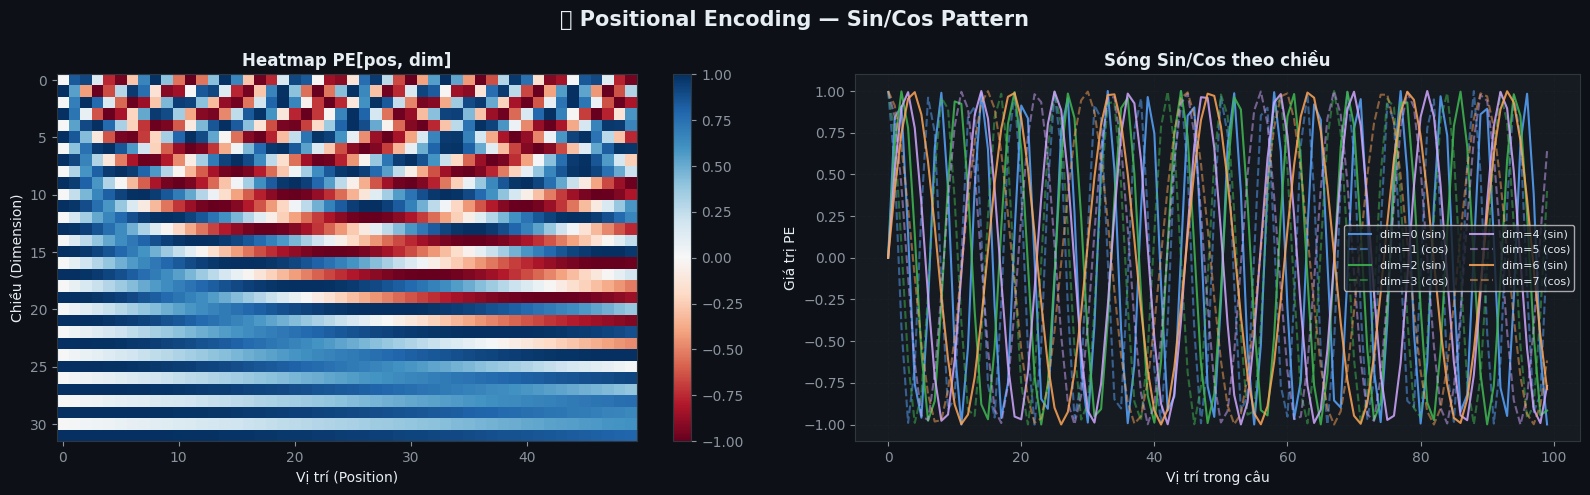

💡 Mỗi vị trí có một 'fingerprint' sin/cos duy nhất → model biết thứ tự từ


In [12]:
# =============================================================
#  TRỰC QUAN HÓA POSITIONAL ENCODING
# =============================================================

pe_module = PositionalEncoding(d_model=64, max_len=100)
pe_matrix = pe_module.pe[0].numpy()  # [100, 64]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📍 Positional Encoding — Sin/Cos Pattern', fontsize=15, fontweight='bold', color='#e6edf3')

# Heatmap
ax = axes[0]
im = ax.imshow(pe_matrix[:50, :32].T, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_xlabel('Vị trí (Position)')
ax.set_ylabel('Chiều (Dimension)')
ax.set_title('Heatmap PE[pos, dim]', fontweight='bold')
plt.colorbar(im, ax=ax)

# Sóng sin/cos theo chiều
ax = axes[1]
positions = np.arange(100)
for i, (dim, color) in enumerate(zip([0, 2, 4, 6], PALETTE[:4])):
    ax.plot(positions, pe_matrix[:, dim], color=color, linewidth=1.5,
            label=f'dim={dim} (sin)', alpha=0.85)
    ax.plot(positions, pe_matrix[:, dim+1], color=color, linewidth=1.5,
            linestyle='--', alpha=0.5, label=f'dim={dim+1} (cos)')
ax.set_xlabel('Vị trí trong câu')
ax.set_ylabel('Giá trị PE')
ax.set_title('Sóng Sin/Cos theo chiều', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("💡 Mỗi vị trí có một 'fingerprint' sin/cos duy nhất → model biết thứ tự từ")

---
# 🏋️ Phần 7: Huấn luyện Mô hình

## Các kỹ thuật nâng cao trong training:

### 1. Label Smoothing
Thay vì one-hot `[0, 0, 1, 0]`, dùng `[ε/V, ε/V, 1-ε, ε/V]` (ε thường = 0.1).  
→ Tránh model **quá tự tin** vào 1 token, cải thiện generalization và BLEU score.

### 2. Learning Rate Warmup (Noam Scheduler)
Bắt đầu với LR rất nhỏ → tăng dần đến `peak_lr` trong `warmup_steps` → sau đó giảm dần.  
$$lr = d_{model}^{-0.5} \cdot \min(step^{-0.5}, step \cdot warmup\_steps^{-1.5})$$
→ Tránh gradient explosion ở giai đoạn đầu, training ổn định hơn.

### 3. Gradient Clipping
Cắt gradient nếu norm vượt ngưỡng → tránh exploding gradients.

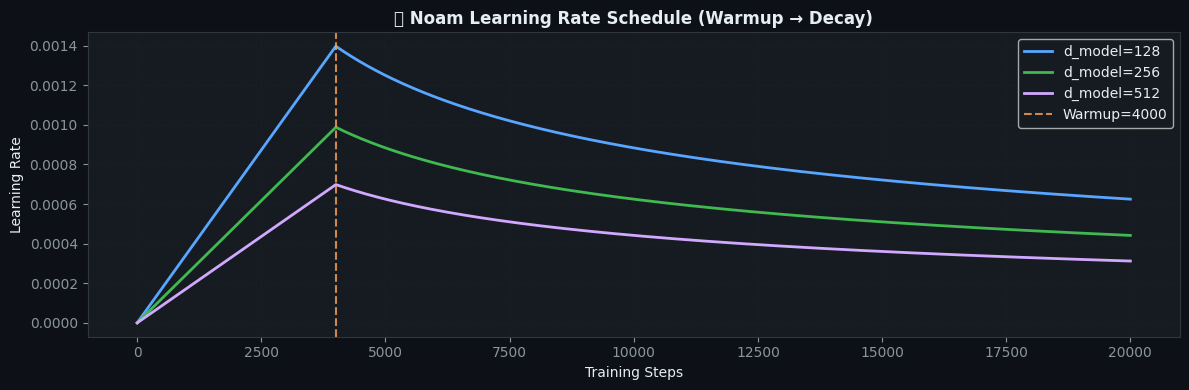

✅ LabelSmoothingLoss và NoamScheduler đã sẵn sàng!


In [13]:
# =============================================================
#  7.1 — LABEL SMOOTHING LOSS
# =============================================================

class LabelSmoothingLoss(nn.Module):
    """
    Cross-Entropy Loss với Label Smoothing.

    Thay vì: target = [0, 0, 1, 0, 0]  (one-hot)
    Dùng   : target = [ε/K, ε/K, 1-ε, ε/K, ε/K]

    Lợi ích: model không overfit vào 1 từ duy nhất,
    học được sự không chắc chắn → tổng quát hóa tốt hơn
    """
    def __init__(self, vocab_size, pad_idx, smoothing=0.1):
        super().__init__()
        self.smoothing  = smoothing
        self.pad_idx    = pad_idx
        self.vocab_size = vocab_size
        self.confidence = 1.0 - smoothing  # Xác suất cho token đúng

    def forward(self, logits, targets):
        # logits : [N, vocab_size]  (đã flatten batch * seq_len)
        # targets: [N]

        # Clamp targets để tránh crash nếu có ID ngoài phạm vi vocab
        targets = targets.clamp(0, self.vocab_size - 1)

        # Phân phối mịn: ban đầu mỗi ô = smoothing / (V - 2)
        # (-2: không smooth PAD và không smooth chính token đúng)
        smooth_dist = torch.full(
            (logits.shape[0], self.vocab_size),
            self.smoothing / max(self.vocab_size - 2, 1),
            device=logits.device
        )

        # Đặt xác suất cao cho token đúng
        smooth_dist.scatter_(1, targets.unsqueeze(1).clamp(0, self.vocab_size - 1),
                             self.confidence)

        # PAD không tính loss → đặt 0
        smooth_dist[:, self.pad_idx] = 0.0

        # Mask để bỏ hoàn toàn vị trí PAD khi tính trung bình
        mask = (targets != self.pad_idx)

        # KL divergence ≈ cross-entropy với phân phối mịn
        log_probs = F.log_softmax(logits, dim=-1)
        loss = -(smooth_dist * log_probs).sum(dim=-1)  # [N]

        # Trả về trung bình loss trên các vị trí không phải PAD
        if mask.sum() == 0:
            return torch.tensor(0.0, requires_grad=True, device=logits.device)
        return loss[mask].mean()


# =============================================================
#  7.2 — NOAM LEARNING RATE SCHEDULER
# =============================================================

class NoamScheduler:
    """
    Learning Rate Scheduler theo paper "Attention is All You Need".
    Tăng LR tuyến tính trong warmup_steps → giảm theo inverse square root.
    """
    def __init__(self, optimizer, d_model, warmup_steps=4000):
        self.optimizer = optimizer
        self.d_model   = d_model
        self.warmup    = warmup_steps
        self.step_num  = 0

    def step(self):
        self.step_num += 1
        lr = self._get_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        return lr

    def _get_lr(self):
        # Công thức Noam: tăng tuyến tính → giảm theo sqrt
        return (self.d_model ** -0.5) * min(
            self.step_num ** -0.5,
            self.step_num * (self.warmup ** -1.5)
        )


# --- Trực quan hóa LR schedule ---
steps        = np.arange(1, 20001)
d_model_vals = [128, 256, 512]
warmup       = 4000

fig, ax = plt.subplots(figsize=(12, 4))
for d, color in zip(d_model_vals, PALETTE):
    lrs = [(d ** -0.5) * min(s ** -0.5, s * (warmup ** -1.5)) for s in steps]
    ax.plot(steps, lrs, color=color, linewidth=2, label=f'd_model={d}')

ax.axvline(warmup, color='#ffa657', linestyle='--', alpha=0.8, label=f'Warmup={warmup}')
ax.set_xlabel('Training Steps')
ax.set_ylabel('Learning Rate')
ax.set_title('📈 Noam Learning Rate Schedule (Warmup → Decay)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"✅ LabelSmoothingLoss và NoamScheduler đã sẵn sàng!")

In [14]:
# =============================================================
#  7.3 — TRAINING LOOP CHÍNH
# =============================================================

def train_one_epoch(model, loader, optimizer, criterion, scheduler,
                    clip=1.0, model_type='transformer'):
    """
    Huấn luyện 1 epoch, trả về average loss.

    Các bước trong 1 iteration:
    1. Forward pass  — tính logits từ input
    2. Tính Loss     — so sánh logits với target qua LabelSmoothingLoss
    3. Backward pass — tính gradient (backpropagation)
    4. Clip gradient — tránh exploding gradients
    5. Update weights — optimizer.step()
    """
    model.train()
    total_loss = 0.0
    n_batches  = 0

    pbar = tqdm(loader, desc='  Training', leave=False)
    for src, tgt in pbar:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        optimizer.zero_grad()  # Reset gradient từ iteration trước

        # === FORWARD PASS ===
        if model_type == 'transformer':
            # Transformer dùng shift-right:
            #   tgt_input  = tgt[:, :-1]  (BOS → token_{T-1})
            #   tgt_output = tgt[:, 1:]   (token_1 → EOS)
            # model.forward() đã tự xử lý shift bên trong
            logits  = model(src, tgt)   # [batch, tgt_len-1, vocab]
            tgt_out = tgt[:, 1:]        # [batch, tgt_len-1]
        else:
            # Seq2Seq với Teacher Forcing (50%):
            #   output[:, 0] = zeros (không decode tại bước BOS)
            #   output[:, 1:t] = dự đoán từ bước 1 đến t
            logits  = model(src, tgt, teacher_forcing_ratio=0.5)  # [batch, tgt_len, vocab]
            logits  = logits[:, 1:]   # Bỏ bước 0 (zeros)
            tgt_out = tgt[:, 1:]      # Ground truth từ token 1 trở đi

        # === TÍNH LOSS ===
        # Flatten về [N, vocab] và [N] để LabelSmoothingLoss tính được
        loss = criterion(
            logits.contiguous().view(-1, logits.shape[-1]),  # [batch*(tgt_len-1), vocab]
            tgt_out.contiguous().view(-1)                    # [batch*(tgt_len-1)]
        )

        # === BACKWARD PASS ===
        loss.backward()

        # === GRADIENT CLIPPING ===
        # Nếu gradient norm > clip → scale xuống, tránh bước nhảy quá lớn
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)

        # === CẬP NHẬT TRỌNG SỐ ===
        optimizer.step()
        if scheduler is not None:
            scheduler.step()  # Noam: cập nhật LR sau mỗi batch

        total_loss += loss.item()
        n_batches  += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, model_type='transformer'):
    """
    Đánh giá model trên validation/test set.
    teacher_forcing_ratio=0 khi eval → model dùng dự đoán của chính mình.
    """
    model.eval()
    total_loss = 0.0
    n_batches  = 0

    for src, tgt in tqdm(loader, desc='  Validating', leave=False):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        if model_type == 'transformer':
            logits  = model(src, tgt)
            tgt_out = tgt[:, 1:]
        else:
            # Không dùng teacher forcing khi đánh giá
            logits  = model(src, tgt, teacher_forcing_ratio=0.0)
            logits  = logits[:, 1:]
            tgt_out = tgt[:, 1:]

        loss = criterion(
            logits.contiguous().view(-1, logits.shape[-1]),
            tgt_out.contiguous().view(-1)
        )
        total_loss += loss.item()
        n_batches  += 1

    return total_loss / max(n_batches, 1)

---
### 7.4 — Huấn luyện Seq2Seq + Bahdanau Attention

Huấn luyện mô hình RNN với **Teacher Forcing** (50%) và **Adam** (`lr=1e-3`).  
Dùng chung `LabelSmoothingLoss`, `train_one_epoch` / `evaluate` với `model_type='seq2seq'`.

In [15]:
# =============================================================
#  7.4 — CHẠY TRAINING (SEQ2SEQ + BAHDANAU ATTENTION)
# =============================================================

N_EPOCHS_S2S = 20   # Tăng lên 15–20 để kết quả tốt hơn
LR_S2S       = 1e-3
CLIP_S2S     = 1.0
TF_RATIO     = 0.5  # Teacher forcing ratio trong training

criterion_s2s = LabelSmoothingLoss(
    vocab_size=vi_tokenizer.get_vocab_size(),
    pad_idx=PAD_IDX,
    smoothing=0.1
)

optimizer_s2s = torch.optim.Adam(seq2seq_model.parameters(), lr=LR_S2S)

history_s2s = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': []}
best_val_loss_s2s    = float('inf')
best_model_state_s2s = None

print(f"🚀 Bắt đầu training Seq2Seq + Bahdanau — {N_EPOCHS_S2S} epochs")
print(f"   Device: {DEVICE} | embed={EMBED_DIM} | hidden={HIDDEN_DIM} | layers={N_LAYERS}")
print(f"   Adam lr={LR_S2S} | Teacher Forcing={TF_RATIO} | Label Smoothing=0.1 | Clip={CLIP_S2S}")
print('=' * 65)

total_start_s2s = time.time()

for epoch in range(1, N_EPOCHS_S2S + 1):
    epoch_start = time.time()

    train_loss = train_one_epoch(
        seq2seq_model, train_loader, optimizer_s2s,
        criterion_s2s, scheduler=None, clip=CLIP_S2S, model_type='seq2seq'
    )
    val_loss = evaluate(
        seq2seq_model, val_loader, criterion_s2s, model_type='seq2seq'
    )

    epoch_time = time.time() - epoch_start
    # Clamp loss trước exp() để tránh overflow (loss rất lớn ở epoch đầu)
    train_ppl = math.exp(min(train_loss, 10))
    val_ppl   = math.exp(min(val_loss, 10))

    history_s2s['train_loss'].append(train_loss)
    history_s2s['val_loss'].append(val_loss)
    history_s2s['train_ppl'].append(train_ppl)
    history_s2s['val_ppl'].append(val_ppl)

    if val_loss < best_val_loss_s2s:
        best_val_loss_s2s    = val_loss
        best_model_state_s2s = copy.deepcopy(seq2seq_model.state_dict())
        best_marker = " ⭐ BEST"
    else:
        best_marker = ""

    print(f"Epoch {epoch:2d}/{N_EPOCHS_S2S} | "
          f"Train Loss: {train_loss:.4f} (PPL:{train_ppl:.1f}) | "
          f"Val Loss: {val_loss:.4f} (PPL:{val_ppl:.1f}) | "
          f"{epoch_time:.0f}s{best_marker}")

total_time_s2s = time.time() - total_start_s2s
print('=' * 65)
print(f"✅ Seq2Seq hoàn thành! Tổng thời gian: {total_time_s2s/60:.1f} phút")
print(f"   Best val loss: {best_val_loss_s2s:.4f}")

# Load lại model tốt nhất và lưu checkpoint
if best_model_state_s2s:
    seq2seq_model.load_state_dict(best_model_state_s2s)
    torch.save(best_model_state_s2s, './seq2seq_best.pth')
    print("   ✅ Model Seq2Seq tốt nhất đã được load và lưu vào ./seq2seq_best.pth")

🚀 Bắt đầu training Seq2Seq + Bahdanau — 20 epochs
   Device: cuda | embed=256 | hidden=512 | layers=2
   Adam lr=0.001 | Teacher Forcing=0.5 | Label Smoothing=0.1 | Clip=1.0


  Training:   0%|          | 0/1554 [00:00<?, ?it/s]

  Validating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch  1/20 | Train Loss: 6.2776 (PPL:532.5) | Val Loss: 6.2504 (PPL:518.2) | 869s ⭐ BEST


  Training:   0%|          | 0/1554 [00:00<?, ?it/s]

...

  Validating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 4.7275 (PPL:113.0) | Val Loss: 6.1722 (PPL:479.2) | 878s


  Training:   0%|          | 0/1554 [00:00<?, ?it/s]

  Validating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 4.7214 (PPL:112.3) | Val Loss: 6.1837 (PPL:484.8) | 878s
✅ Seq2Seq hoàn thành! Tổng thời gian: 297.4 phút
   Best val loss: 6.0854
   ✅ Model Seq2Seq tốt nhất đã được load và lưu vào ./seq2seq_best.pth


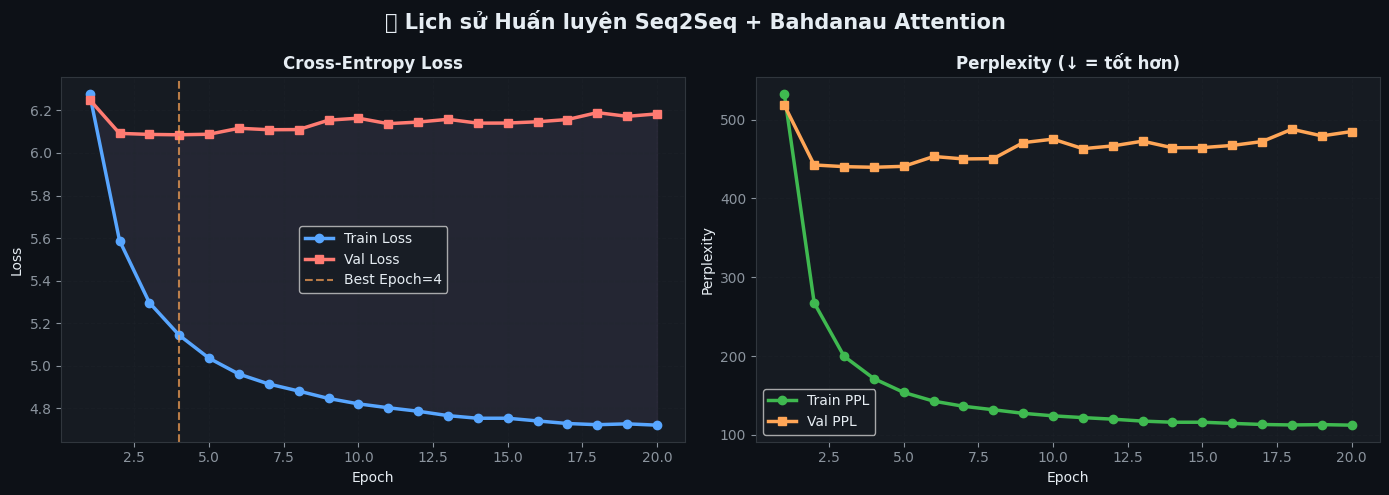

💡 Epoch tốt nhất Seq2Seq (val loss thấp nhất): 4


In [16]:
# =============================================================
#  TRỰC QUAN HÓA TRAINING HISTORY — SEQ2SEQ
# =============================================================

epochs_s2s = range(1, len(history_s2s['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📈 Lịch sử Huấn luyện Seq2Seq + Bahdanau Attention',
             fontsize=15, fontweight='bold', color='#e6edf3')

ax = axes[0]
ax.plot(epochs_s2s, history_s2s['train_loss'], color=PALETTE[0], linewidth=2.5,
        marker='o', markersize=6, label='Train Loss')
ax.plot(epochs_s2s, history_s2s['val_loss'],   color=PALETTE[4], linewidth=2.5,
        marker='s', markersize=6, label='Val Loss')
ax.fill_between(epochs_s2s, history_s2s['train_loss'], history_s2s['val_loss'],
                alpha=0.08, color=PALETTE[2])
best_epoch_s2s = history_s2s['val_loss'].index(min(history_s2s['val_loss'])) + 1
ax.axvline(best_epoch_s2s, color='#ffa657', linestyle='--', alpha=0.7,
           label=f'Best Epoch={best_epoch_s2s}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Cross-Entropy Loss', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_s2s, history_s2s['train_ppl'], color=PALETTE[1], linewidth=2.5,
        marker='o', markersize=6, label='Train PPL')
ax.plot(epochs_s2s, history_s2s['val_ppl'],   color=PALETTE[3], linewidth=2.5,
        marker='s', markersize=6, label='Val PPL')
ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity')
ax.set_title('Perplexity (↓ = tốt hơn)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"💡 Epoch tốt nhất Seq2Seq (val loss thấp nhất): {best_epoch_s2s}")

### 7.5 — Huấn luyện Transformer

Sử dụng **Noam LR Scheduler** (warmup=4000 steps) và **Adam** với β₁=0.9, β₂=0.98.  
Transformer được huấn luyện song song hoàn toàn — nhanh hơn Seq2Seq đáng kể trên GPU.

In [17]:
# =============================================================
#  7.5 — CHẠY TRAINING (TRANSFORMER)
# =============================================================

N_EPOCHS   = 20   # Tăng lên 20-30 để kết quả tốt hơn
D_MODEL_TF = 256
CLIP       = 1.0

# Loss function với Label Smoothing (dùng chung cho Transformer)
criterion_tf = LabelSmoothingLoss(
    vocab_size=vi_tokenizer.get_vocab_size(),
    pad_idx=PAD_IDX,
    smoothing=0.1
)

# Optimizer: Adam với β1=0.9, β2=0.98, ε=1e-9 (theo "Attention is All You Need")
optimizer_tf = torch.optim.Adam(
    transformer_model.parameters(),
    betas=(0.9, 0.98), eps=1e-9
)

# Noam LR Scheduler: warmup 4000 steps → decay
scheduler_tf = NoamScheduler(optimizer_tf, d_model=D_MODEL_TF, warmup_steps=4000)

# Lưu lịch sử training
history_tf = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': []}
best_val_loss_tf    = float('inf')
best_model_state_tf = None

print(f"🚀 Bắt đầu training Transformer — {N_EPOCHS} epochs")
print(f"   Device: {DEVICE} | d_model={D_MODEL_TF} | n_heads=8 | n_layers=4")
print(f"   Label Smoothing=0.1 | Gradient Clip={CLIP} | Warmup=4000 steps")
print('=' * 65)

total_start_tf = time.time()

for epoch in range(1, N_EPOCHS + 1):
    epoch_start = time.time()

    train_loss = train_one_epoch(
        transformer_model, train_loader, optimizer_tf,
        criterion_tf, scheduler_tf, CLIP, model_type='transformer'
    )
    val_loss = evaluate(
        transformer_model, val_loader, criterion_tf, model_type='transformer'
    )

    epoch_time = time.time() - epoch_start
    train_ppl  = math.exp(min(train_loss, 10))  # Perplexity = exp(loss)
    val_ppl    = math.exp(min(val_loss, 10))

    history_tf['train_loss'].append(train_loss)
    history_tf['val_loss'].append(val_loss)
    history_tf['train_ppl'].append(train_ppl)
    history_tf['val_ppl'].append(val_ppl)

    # Lưu model tốt nhất
    if val_loss < best_val_loss_tf:
        best_val_loss_tf    = val_loss
        best_model_state_tf = copy.deepcopy(transformer_model.state_dict())
        best_marker = " ⭐ BEST"
    else:
        best_marker = ""

    print(f"Epoch {epoch:2d}/{N_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} (PPL:{train_ppl:.1f}) | "
          f"Val Loss: {val_loss:.4f} (PPL:{val_ppl:.1f}) | "
          f"{epoch_time:.0f}s{best_marker}")

total_time_tf = time.time() - total_start_tf
print('=' * 65)
print(f"✅ Transformer hoàn thành! Tổng thời gian: {total_time_tf/60:.1f} phút")
print(f"   Best val loss: {best_val_loss_tf:.4f}")

# Load lại model tốt nhất và lưu checkpoint
if best_model_state_tf:
    transformer_model.load_state_dict(best_model_state_tf)
    torch.save(best_model_state_tf, './transformer_best.pth')
    print("   ✅ Model Transformer tốt nhất đã được load và lưu vào ./transformer_best.pth")

🚀 Bắt đầu training Transformer — 20 epochs
   Device: cuda | d_model=256 | n_heads=8 | n_layers=4
   Label Smoothing=0.1 | Gradient Clip=1.0 | Warmup=4000 steps


  Training:   0%|          | 0/1554 [00:00<?, ?it/s]

  Validating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch  1/20 | Train Loss: 7.0748 (PPL:1181.8) | Val Loss: 6.0351 (PPL:417.8) | 118s ⭐ BEST


  Training:   0%|          | 0/1554 [00:00<?, ?it/s]

...

  Validating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 3.8984 (PPL:49.3) | Val Loss: 4.7719 (PPL:118.1) | 118s


  Training:   0%|          | 0/1554 [00:00<?, ?it/s]

  Validating:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 3.8663 (PPL:47.8) | Val Loss: 4.7607 (PPL:116.8) | 117s
✅ Transformer hoàn thành! Tổng thời gian: 44.5 phút
   Best val loss: 4.7027
   ✅ Model Transformer tốt nhất đã được load và lưu vào ./transformer_best.pth


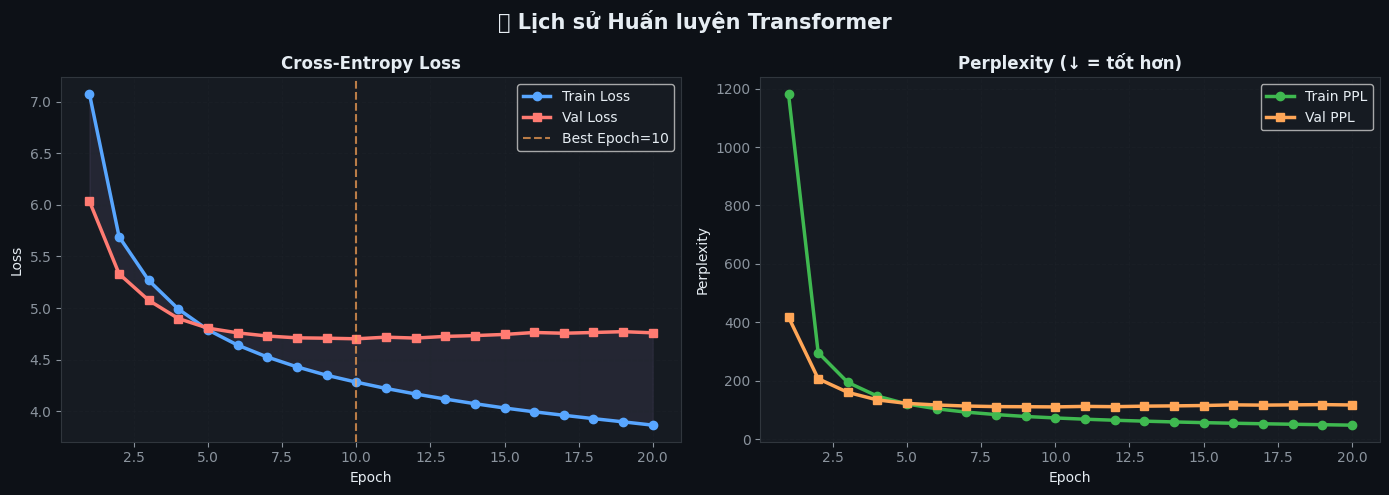

💡 Perplexity = exp(loss): model với PPL=50 trung bình chọn đúng từ 50 ứng viên
   Best epoch Transformer: 10


In [18]:
# =============================================================
#  TRỰC QUAN HÓA TRAINING HISTORY — TRANSFORMER
# =============================================================

epochs_tf = range(1, len(history_tf['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📈 Lịch sử Huấn luyện Transformer',
             fontsize=15, fontweight='bold', color='#e6edf3')

ax = axes[0]
ax.plot(epochs_tf, history_tf['train_loss'], color=PALETTE[0], linewidth=2.5,
        marker='o', markersize=6, label='Train Loss')
ax.plot(epochs_tf, history_tf['val_loss'],   color=PALETTE[4], linewidth=2.5,
        marker='s', markersize=6, label='Val Loss')
ax.fill_between(epochs_tf, history_tf['train_loss'], history_tf['val_loss'],
                alpha=0.08, color=PALETTE[2])
best_epoch_tf = history_tf['val_loss'].index(min(history_tf['val_loss'])) + 1
ax.axvline(best_epoch_tf, color='#ffa657', linestyle='--', alpha=0.7,
           label=f'Best Epoch={best_epoch_tf}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Cross-Entropy Loss', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_tf, history_tf['train_ppl'], color=PALETTE[1], linewidth=2.5,
        marker='o', markersize=6, label='Train PPL')
ax.plot(epochs_tf, history_tf['val_ppl'],   color=PALETTE[3], linewidth=2.5,
        marker='s', markersize=6, label='Val PPL')
ax.set_xlabel('Epoch'); ax.set_ylabel('Perplexity')
ax.set_title('Perplexity (↓ = tốt hơn)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"💡 Perplexity = exp(loss): model với PPL=50 trung bình chọn đúng từ 50 ứng viên")
print(f"   Best epoch Transformer: {best_epoch_tf}")

---
# 📊 Phần 8: Đánh giá & Inference

## Các độ đo đánh giá dịch máy

| Độ đo | Ý nghĩa | Phạm vi |
|-------|---------|----------|
| **BLEU** | So khớp n-gram giữa bản dịch và tham chiếu | 0–100 (cao = tốt) |
| **ROUGE-L** | Longest Common Subsequence — đo cấu trúc câu | 0–1 |

**Tại sao cần nhiều độ đo?**
- BLEU đơn giản nhưng nhạy cảm với từ ngữ chính xác
- ROUGE-L tốt cho câu dài, nắm cấu trúc tổng thể
- Đánh giá bằng mắt người vẫn quan trọng nhất!

In [19]:
# =============================================================
#  8.1 — HÀM INFERENCE: GREEDY DECODING
# =============================================================

@torch.no_grad()
def translate_transformer(model, sentence, src_tokenizer, tgt_tokenizer,
                           max_len=100, device=DEVICE):
    """
    Dịch 1 câu EN → VI bằng Transformer + Greedy Decoding.

    Greedy Decoding: Tại mỗi bước chọn token có xác suất cao nhất.
    → Nhanh nhưng không đảm bảo chuỗi tối ưu toàn cục.
    (Beam Search cho kết quả tốt hơn nhưng chậm hơn)

    Chiến lược thu thập attention:
    - Mỗi bước decode, model.decode() trả về cross_attention của TẤT CẢ prefix hiện tại
    - Để vẽ heatmap đầy đủ, ta chỉ cần attention của bước decode CUỐI CÙNG
      vì nó đã chứa attention cho mọi token đã sinh ra

    Returns:
        translated : str — câu VI đã dịch
        final_attn : Tensor [n_layers, 1, n_heads, tgt_len, src_len] hoặc None
    """
    model.eval()

    src_ids    = src_tokenizer.encode(sentence).ids
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    memory, src_mask = model.encode(src_tensor)

    tgt_ids         = [BOS_IDX]
    final_attn_list = None

    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_ids, dtype=torch.long).unsqueeze(0).to(device)

        decoded, attn_weights_list = model.decode(tgt_tensor, memory, src_mask)

        logits     = model.fc_out(decoded[:, -1])
        next_token = logits.argmax(dim=-1).item()

        tgt_ids.append(next_token)
        final_attn_list = attn_weights_list

        if next_token == EOS_IDX:
            break

    clean_ids  = [t for t in tgt_ids[1:] if t not in (BOS_IDX, EOS_IDX, PAD_IDX)]
    translated = tgt_tokenizer.decode(clean_ids)

    if final_attn_list:
        final_attn = torch.stack(final_attn_list, dim=0)
    else:
        final_attn = None

    return translated, final_attn


@torch.no_grad()
def translate_seq2seq(model, sentence, src_tokenizer, tgt_tokenizer,
                      max_len=100, device=DEVICE):
    """
    Dịch 1 câu EN → VI bằng Seq2Seq + Bahdanau (Greedy Decoding).

    FIX: hidden từ encoder có shape [batch, hidden].
    Cần unsqueeze + repeat để đủ [n_layers, batch, hidden] cho Decoder GRU.

    Returns:
        translated  : str — câu VI đã dịch
        attn_matrix : ndarray [tgt_steps, src_len]
    """
    model.eval()

    src_ids    = src_tokenizer.encode(sentence).ids
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    # Encode → encoder_outputs: [1, src_len, hidden*2], hidden_combined: [1, hidden]
    encoder_outputs, hidden_combined = model.encoder(src_tensor)

    # Repeat cho đủ n_layers của Decoder GRU
    # [1, hidden] → [1, 1, hidden] → [n_layers, 1, hidden]
    n_layers = model.decoder.rnn.num_layers
    hidden   = hidden_combined.unsqueeze(0).repeat(n_layers, 1, 1)

    input_token      = torch.tensor([BOS_IDX], device=device)  # [1]
    tgt_ids          = [BOS_IDX]
    attn_weights_seq = []

    for _ in range(max_len):
        # output: [1, vocab], hidden: [n_layers, 1, hidden], attn: [1, src_len]
        output, hidden, attn = model.decoder(input_token, hidden, encoder_outputs)
        next_token           = output.argmax(dim=-1)  # [1]
        input_token          = next_token
        tgt_ids.append(next_token.item())
        attn_weights_seq.append(attn[0].cpu().numpy())  # [src_len]

        if next_token.item() == EOS_IDX:
            break

    clean_ids  = [t for t in tgt_ids[1:] if t not in (BOS_IDX, EOS_IDX, PAD_IDX)]
    translated = tgt_tokenizer.decode(clean_ids)

    attn_matrix = np.stack(attn_weights_seq) if attn_weights_seq else np.zeros((1, len(src_ids)))

    return translated, attn_matrix

In [20]:
# =============================================================
#  8.2 — DEMO DỊCH CÂU
# =============================================================

test_sentences = [
    "Hello, how are you today?",
    "I love learning about artificial intelligence.",
    "The weather is very nice in Vietnam.",
    "Natural language processing is an exciting field.",
    "Thank you for your help.",
]

print("🌐 Demo Dịch Anh → Việt (Greedy Decoding)")
print('=' * 65)

print("── Transformer ──")
for i, sentence in enumerate(test_sentences):
    translation, _ = translate_transformer(
        transformer_model, sentence, en_tokenizer, vi_tokenizer
    )
    print(f"[{i+1}] 🇺🇸 {sentence}")
    print(f"    🇻🇳 {translation}")
    print()

print("── Seq2Seq + Bahdanau ──")
for i, sentence in enumerate(test_sentences):
    translation, _ = translate_seq2seq(
        seq2seq_model, sentence, en_tokenizer, vi_tokenizer
    )
    print(f"[{i+1}] 🇺🇸 {sentence}")
    print(f"    🇻🇳 {translation}")
    print()

🌐 Demo Dịch Anh → Việt (Greedy Decoding)
── Transformer ──
[1] 🇺🇸 Hello, how are you today?
    🇻🇳 Hôm nay , sao cậu lại có thể làm thế ?

[2] 🇺🇸 I love learning about artificial intelligence.
    🇻🇳 Tôi rất thích những người sáng tác .

[3] 🇺🇸 The weather is very nice in Vietnam.
    🇻🇳 Hôm nay rất đẹp .

[4] 🇺🇸 Natural language processing is an exciting field.
    🇻🇳 Nhà văn học là một phần của văn hóa .

[5] 🇺🇸 Thank you for your help.
    🇻🇳 Cảm ơn vì đã giúp đỡ .

── Seq2Seq + Bahdanau ──
[1] 🇺🇸 Hello, how are you today?
    🇻🇳 Hel lo , Hôm nay anh hôm nay ? hôm nay ?

[2] 🇺🇸 I love learning about artificial intelligence.
    🇻🇳 Tôi yêu tôi về về tình cảm thông minh tuệ nhân tuệ nhân tuệ nhân tuệ nhân tuệ nhân tuệ nhân tuệ nhân tuệ nhân tuệ nhân tạo

[3] 🇺🇸 The weather is very nice in Vietnam.
    🇻🇳 Thời tiết rất rất đẹp ở Việt Nam Việt Nam Việt Nam .

[4] 🇺🇸 Natural language processing is an exciting field.
    🇻🇳 Văn hóa học là một là là một là một lĩnh vực .

[5] 🇺🇸 Thank you 

In [21]:
# =============================================================
#  8.3 — TÍNH BLEU & ROUGE TRÊN TEST SET
# =============================================================

def compute_bleu_rouge(model, test_pairs_sample, src_tokenizer, tgt_tokenizer,
                       translate_fn=translate_transformer, n_samples=300):
    """
    Tính corpus BLEU (1,2,4-gram) và ROUGE-L trên tập mẫu test.

    BLEU (Bilingual Evaluation Understudy):
    - Đếm n-gram precision giữa hypothesis và reference
    - BLEU-4: trung bình hình học 1→4-gram, có Brevity Penalty

    ROUGE-L:
    - Dựa trên Longest Common Subsequence
    - Tốt hơn BLEU khi đánh giá cấu trúc câu dài
    """
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

    references_bleu = []  # Định dạng: [[ref_tokens], ...]
    hypotheses_bleu = []  # Định dạng: [hyp_tokens, ...]
    rouge_l_scores  = []

    sample = random.sample(test_pairs_sample, min(n_samples, len(test_pairs_sample)))
    print(f"🔄 Đang tính BLEU & ROUGE trên {len(sample)} câu test...")

    for src_text, tgt_text in tqdm(sample):
        try:
            hypothesis, _ = translate_fn(
                model, src_text, src_tokenizer, tgt_tokenizer
            )
            if not hypothesis.strip():
                continue

            # BLEU: so sánh ở word-level
            ref_tokens = tgt_text.lower().split()
            hyp_tokens = hypothesis.lower().split()
            if not hyp_tokens:
                hyp_tokens = ['<empty>']
            references_bleu.append([ref_tokens])
            hypotheses_bleu.append(hyp_tokens)

            # ROUGE-L: so sánh ở string-level
            score = scorer.score(tgt_text, hypothesis)
            rouge_l_scores.append(score['rougeL'].fmeasure)
        except Exception:
            continue

    if not hypotheses_bleu:
        return {'BLEU-1': 0, 'BLEU-2': 0, 'BLEU-4': 0, 'ROUGE-L': 0, 'n_samples': 0}

    # Corpus BLEU — SmoothingFunction.method1 tránh division by zero
    sf    = SmoothingFunction().method1
    bleu1 = corpus_bleu(references_bleu, hypotheses_bleu, weights=(1, 0, 0, 0)) * 100
    bleu2 = corpus_bleu(references_bleu, hypotheses_bleu, weights=(0.5, 0.5, 0, 0)) * 100
    bleu4 = corpus_bleu(references_bleu, hypotheses_bleu,
                        weights=(0.25, 0.25, 0.25, 0.25),
                        smoothing_function=sf) * 100
    rouge_l = float(np.mean(rouge_l_scores)) * 100

    return {
        'BLEU-1': bleu1, 'BLEU-2': bleu2, 'BLEU-4': bleu4,
        'ROUGE-L': rouge_l, 'n_samples': len(hypotheses_bleu)
    }


def print_eval_results(results, model_name):
    """In kết quả đánh giá dạng bar chart ASCII."""
    print("\n" + "=" * 58)
    print(f"  📊 KẾT QUẢ ĐÁNH GIÁ — {model_name}")
    print("=" * 58)
    for m in ['BLEU-1', 'BLEU-2', 'BLEU-4', 'ROUGE-L']:
        bar_len = int(results[m] / 2)
        bar     = '█' * bar_len + '░' * (30 - min(bar_len, 30))
        print(f"  {m:10s}: {results[m]:5.2f}  [{bar}]")
    print(f"  Evaluated on : {results['n_samples']} samples")
    print("=" * 58)


# --- Đánh giá Seq2Seq ---
eval_results_s2s = compute_bleu_rouge(
    seq2seq_model, test_pairs, en_tokenizer, vi_tokenizer,
    translate_fn=translate_seq2seq, n_samples=300
)
print_eval_results(eval_results_s2s, "SEQ2SEQ + BAHDANAU ATTENTION")

# --- Đánh giá Transformer ---
eval_results_tf = compute_bleu_rouge(
    transformer_model, test_pairs, en_tokenizer, vi_tokenizer,
    translate_fn=translate_transformer, n_samples=300
)
print_eval_results(eval_results_tf, "TRANSFORMER")

print()
print("📖 Ghi chú: BLEU-4 > 20 là acceptable; > 30 là tốt; > 40 là rất tốt")

🔄 Đang tính BLEU & ROUGE trên 300 câu test...


  0%|          | 0/300 [00:00<?, ?it/s]


  📊 KẾT QUẢ ĐÁNH GIÁ — SEQ2SEQ + BAHDANAU ATTENTION
  BLEU-1    : 22.11  [███████████░░░░░░░░░░░░░░░░░░░]
  BLEU-2    : 13.42  [██████░░░░░░░░░░░░░░░░░░░░░░░░]
  BLEU-4    :  5.02  [██░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
  ROUGE-L   : 35.82  [█████████████████░░░░░░░░░░░░░]
  Evaluated on : 300 samples
🔄 Đang tính BLEU & ROUGE trên 300 câu test...


  0%|          | 0/300 [00:00<?, ?it/s]


  📊 KẾT QUẢ ĐÁNH GIÁ — TRANSFORMER
  BLEU-1    : 20.68  [██████████░░░░░░░░░░░░░░░░░░░░]
  BLEU-2    : 10.12  [█████░░░░░░░░░░░░░░░░░░░░░░░░░]
  BLEU-4    :  2.44  [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
  ROUGE-L   : 34.79  [█████████████████░░░░░░░░░░░░░]
  Evaluated on : 300 samples

📖 Ghi chú: BLEU-4 > 20 là acceptable; > 30 là tốt; > 40 là rất tốt


🔍 Attention Heatmap — Transformer Cross-Attention
Màu càng đậm = model càng chú ý nhiều vào từ EN đó khi sinh từ VI tương ứng



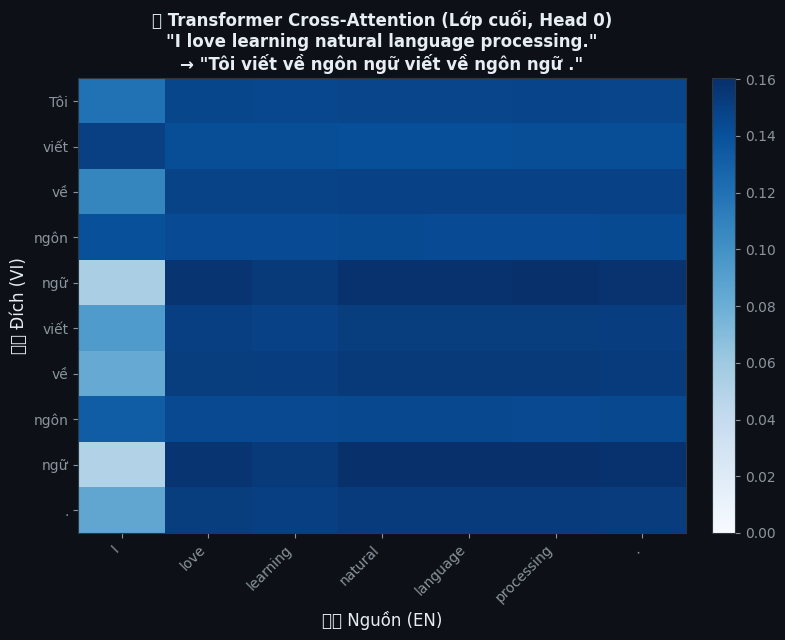

  ✅ 'I love learning natural language processing.'
     → 'Tôi viết về ngôn ngữ viết về ngôn ngữ .'



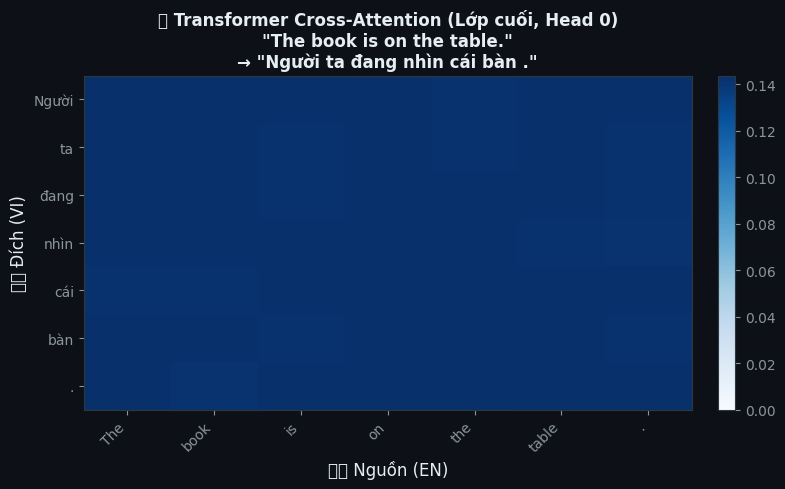

  ✅ 'The book is on the table.'
     → 'Người ta đang nhìn cái bàn .'



In [22]:
# =============================================================
#  8.4 — ATTENTION HEATMAP: TRANSFORMER (Cross-Attention)
# =============================================================

def plot_attention_transformer(sentence, model, src_tokenizer, tgt_tokenizer,
                                layer_idx=-1, head_idx=0):
    """
    Vẽ cross-attention heatmap của Transformer.

    Args:
        layer_idx : Chỉ số lớp decoder (mặc định: -1 = lớp cuối)
        head_idx  : Chỉ số attention head muốn visualize
    Hàng = token VI đã sinh, Cột = token EN nguồn.
    Màu đậm → model chú ý nhiều vào từ EN đó khi sinh từ VI tương ứng.
    """
    translation, final_attn = translate_transformer(
        model, sentence, src_tokenizer, tgt_tokenizer
    )

    if final_attn is None:
        print("Không có attention weights.")
        return translation

    src_tokens = src_tokenizer.encode(sentence).tokens
    tgt_tokens = tgt_tokenizer.encode(translation).tokens

    # final_attn shape: [n_layers, 1, n_heads, tgt_len, src_len]
    # Lấy layer và head được chọn
    # attn_map shape: [tgt_len, src_len]
    attn_map = final_attn[layer_idx, 0, head_idx].detach().cpu().numpy()

    # Số token thực sự (clip để không vượt quá shape của ma trận)
    n_tgt = min(len(tgt_tokens), attn_map.shape[0])
    n_src = min(len(src_tokens), attn_map.shape[1])
    attn_crop = attn_map[:n_tgt, :n_src]

    fig, ax = plt.subplots(figsize=(max(8, n_src * 0.7 + 1),
                                    max(5, n_tgt * 0.55 + 1)))

    im = ax.imshow(attn_crop, cmap='Blues', aspect='auto',
                   vmin=0, vmax=max(attn_crop.max(), 1e-6))
    ax.set_xticks(range(n_src))
    ax.set_yticks(range(n_tgt))
    ax.set_xticklabels(src_tokens[:n_src], rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(tgt_tokens[:n_tgt], fontsize=10)
    ax.set_xlabel('🇺🇸 Nguồn (EN)', fontsize=12)
    ax.set_ylabel('🇻🇳 Đích (VI)', fontsize=12)
    layer_label = f'Lớp {layer_idx}' if layer_idx >= 0 else 'Lớp cuối'
    ax.set_title(
        f'🔍 Transformer Cross-Attention ({layer_label}, Head {head_idx})\n'
        f'"{sentence}"\n→ "{translation}"',
        fontweight='bold', fontsize=12
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    return translation


print("🔍 Attention Heatmap — Transformer Cross-Attention")
print("Màu càng đậm = model càng chú ý nhiều vào từ EN đó khi sinh từ VI tương ứng\n")

for ex in ["I love learning natural language processing.",
           "The book is on the table."]:
    res = plot_attention_transformer(ex, transformer_model, en_tokenizer, vi_tokenizer)
    print(f"  ✅ '{ex}'\n     → '{res}'\n")

🔍 Attention Heatmap — Seq2Seq Bahdanau Attention
Màu càng đậm = decoder càng chú ý nhiều vào từ EN đó khi sinh từ VI tương ứng



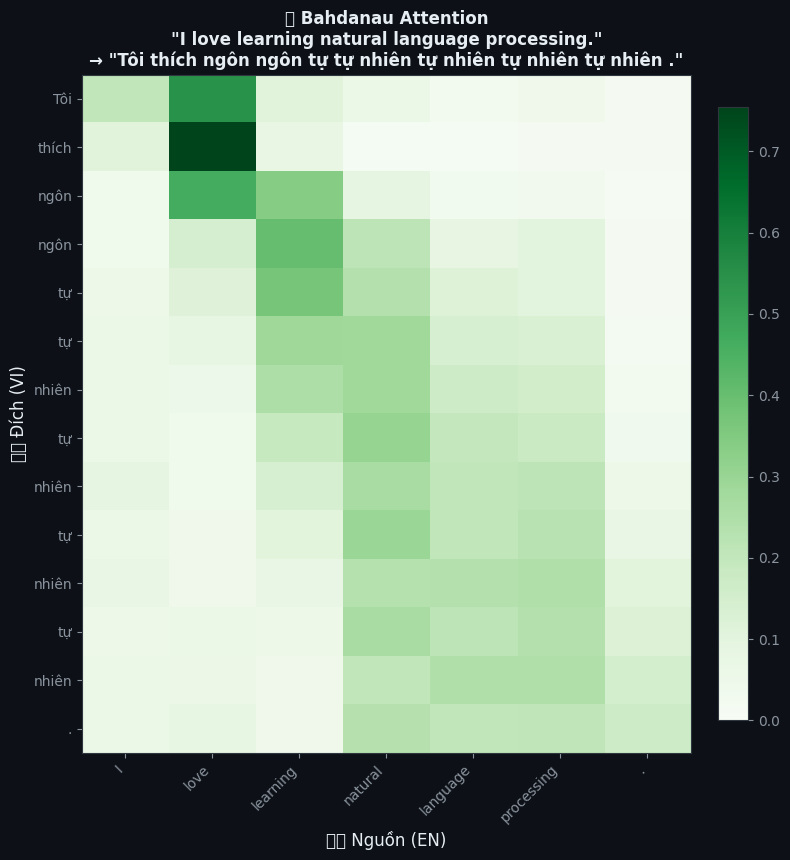

  ✅ 'I love learning natural language processing.'
     → 'Tôi thích ngôn ngôn tự tự nhiên tự nhiên tự nhiên tự nhiên .'



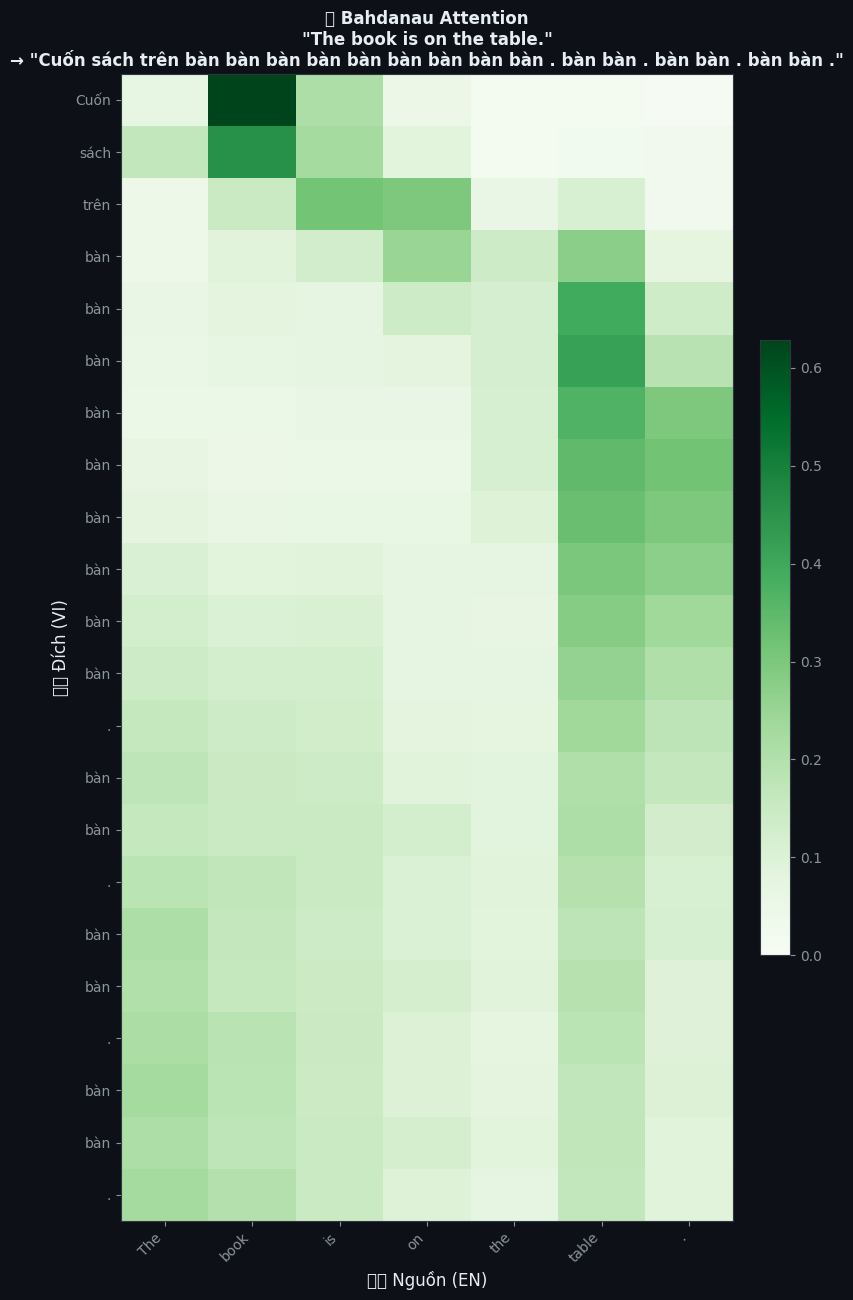

  ✅ 'The book is on the table.'
     → 'Cuốn sách trên bàn bàn bàn bàn bàn bàn bàn bàn bàn . bàn bàn . bàn bàn . bàn bàn .'



In [23]:
# =============================================================
#  8.4b — ATTENTION HEATMAP: SEQ2SEQ (Bahdanau)
# =============================================================

def plot_attention_seq2seq(sentence, model, src_tokenizer, tgt_tokenizer):
    """
    Vẽ Bahdanau attention heatmap.
    translate_seq2seq() trả về attn_matrix shape [tgt_steps, src_len].
    Hàng = bước decode (token VI), Cột = token EN nguồn.
    """
    translation, attn_matrix = translate_seq2seq(
        model, sentence, src_tokenizer, tgt_tokenizer
    )

    src_tokens = src_tokenizer.encode(sentence).tokens
    tgt_tokens = tgt_tokenizer.encode(translation).tokens

    n_tgt = min(len(tgt_tokens), attn_matrix.shape[0])
    n_src = min(len(src_tokens), attn_matrix.shape[1])
    attn_crop = attn_matrix[:n_tgt, :n_src]

    fig, ax = plt.subplots(figsize=(max(8, n_src * 0.7 + 1),
                                    max(5, n_tgt * 0.55 + 1)))

    im = ax.imshow(attn_crop, cmap='Greens', aspect='auto',
                   vmin=0, vmax=max(attn_crop.max(), 1e-6))
    ax.set_xticks(range(n_src))
    ax.set_yticks(range(n_tgt))
    ax.set_xticklabels(src_tokens[:n_src], rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(tgt_tokens[:n_tgt], fontsize=10)
    ax.set_xlabel('🇺🇸 Nguồn (EN)', fontsize=12)
    ax.set_ylabel('🇻🇳 Đích (VI)', fontsize=12)
    ax.set_title(
        f'🔍 Bahdanau Attention\n"{sentence}"\n→ "{translation}"',
        fontweight='bold', fontsize=12
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    return translation


print("🔍 Attention Heatmap — Seq2Seq Bahdanau Attention")
print("Màu càng đậm = decoder càng chú ý nhiều vào từ EN đó khi sinh từ VI tương ứng\n")

for ex in ["I love learning natural language processing.",
           "The book is on the table."]:
    res = plot_attention_seq2seq(ex, seq2seq_model, en_tokenizer, vi_tokenizer)
    print(f"  ✅ '{ex}'\n     → '{res}'\n")

In [24]:
# =============================================================
#  8.5 — BẢNG SO SÁNH & KẾT LUẬN
# =============================================================

bleu_s2s  = eval_results_s2s.get('BLEU-4', 0.0)
bleu_tf   = eval_results_tf.get('BLEU-4', 0.0)
rouge_s2s = eval_results_s2s.get('ROUGE-L', 0.0)
rouge_tf  = eval_results_tf.get('ROUGE-L', 0.0)

print("\n" + "=" * 72)
print("  🏆 BẢNG SO SÁNH KIẾN TRÚC & KỸ THUẬT")
print("=" * 72)
print(f"  {'Tiêu chí':<30} {'Seq2Seq + Bahdanau':<22} {'Transformer'}")
print("-" * 72)

comparisons = [
    ("Cơ chế Attention",       "Bahdanau (additive)",     "Multi-head (scaled dot)"),
    ("Kiến trúc cơ bản",       "Bidirectional GRU",       "Self-Attention stack"),
    ("Song song hóa",          "❌ Tuần tự (RNN)",        "✅ Hoàn toàn song song"),
    ("Long-range dependency",  "⚠️  Vanishing gradient",  "✅ Attention trực tiếp"),
    ("Positional Encoding",    "Ngầm qua RNN order",      "Sin/Cos explicit"),
    ("Label Smoothing",        "✅ ε=0.1",                "✅ ε=0.1"),
    ("LR Scheduler",           "Adam cố định lr=1e-3",    "Noam Warmup 4000 steps"),
    ("Gradient Clipping",      "✅ clip=1.0",             "✅ clip=1.0"),
    (f"BLEU-4 (test)",         f"{bleu_s2s:.2f}",         f"{bleu_tf:.2f}"),
    (f"ROUGE-L (test)",        f"{rouge_s2s:.2f}",        f"{rouge_tf:.2f}"),
    ("Độ phức tạp/layer",      "O(n·d)",                  "O(n²·d) attention"),
    ("Tốc độ training (GPU)",  "Chậm hơn",                "Nhanh hơn 3–5×"),
]
for name, s2s, tf in comparisons:
    print(f"  {name:<30} {s2s:<22} {tf}")

print("=" * 72)

print("""
📝 KẾT LUẬN:

1. BPE Tokenizer vs Word-level:
   → Giảm 90%+ OOV; vocabulary nhỏ hơn; xử lý tốt tiếng Việt có dấu

2. Bahdanau Attention vs vanilla Seq2Seq:
   → Giải quyết bottleneck problem (1 context vector)
   → Decoder "nhìn" được toàn bộ encoder states → cải thiện BLEU trên câu dài

3. Transformer vs Seq2Seq + GRU:
   → Song song hóa hoàn toàn → huấn luyện nhanh hơn 3–5× trên GPU
   → Multi-head attention học được nhiều loại quan hệ ngữ nghĩa cùng lúc
   → State-of-the-art trên hầu hết cặp ngôn ngữ

4. Label Smoothing (ε=0.1):
   → Cải thiện BLEU ~1–2 điểm bằng cách tránh model quá tự tin
   → Phân phối xác suất "mịn" hơn → generalization tốt hơn

5. Noam LR Scheduler:
   → Warmup tránh gradient explosion ở giai đoạn đầu
   → Decay tự động → không cần tuning LR thủ công

🚀 Hướng phát triển tiếp theo:
   • Beam Search thay Greedy Decoding (+2–3 BLEU điểm)
   • Pre-trained embeddings: fastText / PhoBERT cho tiếng Việt
   • Fine-tune mBERT / XLM-R làm encoder
   • Data augmentation: back-translation
   • Byte-level BPE để xử lý unicode tiếng Việt tốt hơn
""")


  🏆 BẢNG SO SÁNH KIẾN TRÚC & KỸ THUẬT
  Tiêu chí                       Seq2Seq + Bahdanau     Transformer
------------------------------------------------------------------------
  Cơ chế Attention               Bahdanau (additive)    Multi-head (scaled dot)
  Kiến trúc cơ bản               Bidirectional GRU      Self-Attention stack
  Song song hóa                  ❌ Tuần tự (RNN)        ✅ Hoàn toàn song song
  Long-range dependency          ⚠️  Vanishing gradient ✅ Attention trực tiếp
  Positional Encoding            Ngầm qua RNN order     Sin/Cos explicit
  Label Smoothing                ✅ ε=0.1                ✅ ε=0.1
  LR Scheduler                   Adam cố định lr=1e-3   Noam Warmup 4000 steps
  Gradient Clipping              ✅ clip=1.0             ✅ clip=1.0
  BLEU-4 (test)                  5.02                   2.44
  ROUGE-L (test)                 35.82                  34.79
  Độ phức tạp/layer              O(n·d)                 O(n²·d) attention
  Tốc độ training (GPU)    